# EDIS 8100 · Week 10 · Game and Emotional Learning Analytics Lab

**Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia**

Guest this week: Chaewon Kim, Southern Illinois University, who joins us for the last hour.

**There is no in-class notebook block this week.** The guest holds the final hour, so the session
itself is the opening, the student-led discussion hour, the guest speaker preparation block, the
break, and the guest. You work through this notebook on your own schedule, before or after we
meet, at whatever pace suits you. Nothing here is collected. The graded submission this week is
the Course Research Project Literature Review, which goes to Canvas separately.

Because you are working through it on your own, the notebook explains more of itself than usual
and marks clearly what to run and what to think about. Questions are welcome at any point,
including questions about a single line of code, and errors along the way are normal.

## What changes this week

The status of the data changes rather than the topic.

You have met minors before: 395 Portuguese secondary school students, most of them fifteen to
eighteen, in week 1 and week 3, school students writing to a test prompt in week 5, nine to twelve
year olds with a robot in week 6. What is different here is that the record is play, unsupervised
by any rubric, logged second by second while a class period ran. These are children who played two
real games, whose play was logged, and whose logs the University of Wisconsin-Madison released
into the public domain so that others could learn from them.

You get **two games**, on purpose.

- **AQUALAB** (*Wake: Tales from the Aqualab*) is a marine-science adventure. A player takes on a
  job, dives, runs experiments, and then has to argue for a conclusion from the evidence they
  gathered.
- **WAVES** (*Wave Combinator*) is a signal-matching puzzle game. A player moves sliders until
  their wave matches a target.

The lab, the logging infrastructure, and the public-domain release are the same. The children, the
game, and the question are different.

## How the notebook goes

In AQUALAB you will find a genuine difficulty spike, and then a genuine-looking result about
persistence: children who kept arguing at the hardest job in the game finished far more of the
game. Section 4 takes that result apart, and much of it turns out to be a fact about the record
rather than a fact about persistence. Then the same question goes to WAVES, where the spike is
sharper still and the persistence result **does not come back**.

A finding that holds in one game and not in the next shows more about generalisation than a tidy
effect would, and nobody planted it here.

## What I hope you leave with

1. Being able to state where a dataset came from before analysing it: who logged it, from whom,
   under what licence, and what the file cannot see.
2. A way of finding the mess in a real telemetry extract, meaning columns that hold one value, a
   category that is not an activity, durations that run backwards, rows with no player at all, and
   answers in two languages, and a habit of saying what each repair costs.
3. A sense of how to summarise a heavily skewed count, and of why the mean is a poor number for
   the hardest job in AQUALAB and the median is not obviously the right one either.
4. Being able to separate a selection question from an effect question when the same event
   switches both variables on, and to carry an interval that respects rows nested inside people.
5. A way of reading an in-game affect item without treating a feeling word as a property of a
   child.
6. A feeling for what happens when a replication in a second game disagrees with the first, and
   for how to report that.

None of these is a coding objective.

## How this notebook works

- Run cells **top to bottom**. Click a cell, then press **Shift + Enter**. Every cell assumes the
  ones above it have run.
- This runs on a temporary machine in the cloud, working on a copy of three published files.
  Nothing is installed on your computer and nothing is written to it. If something looks wrong,
  **Runtime > Restart session and run all** in Colab, or **Kernel > Restart & Run All** in Jupyter,
  resolves almost everything.
- Cells marked **Your turn** already hold a working value. You can run the whole notebook without
  editing anything and nothing will be missing.
- The section marked **Going further (optional)** at the end holds worked solutions to the four
  **Your turn** cells. Please feel free to skip it.
- Coding expertise is not assumed here, and nothing asks you to write code from scratch. Your
  attention is better spent on what the code does to the data and on what each output does and
  does not support.
- The work is done by **pandas** for tables, **numpy** for arithmetic, and **matplotlib** for
  pictures, and nothing else, so that every statistic stays visible.

Markers you will see: **Run the cell below.** · **Let's look at the output.** · **Let's discuss.**
· **Your turn** · **Going further (optional)**

## Reading the code

**Every code cell here runs as written.** You can press Shift and Enter from the top of this
notebook to the bottom without editing anything, and nothing will be missing. That is tested
before the notebook is published: a clean machine with no data on it runs the whole file end to
end.

**The cells marked Your turn already hold a working value.** Changing it and re-running shows what
that choice was doing to the result, which is the point of marking it. If you never touch one, you
still get every finding this notebook is about.

**Where the attention belongs.** Coding skill is not what this course assesses, and nothing from
this notebook is collected. What is worth your time is the interpretation: what the method can
see, what it cannot, and what the output might mean.

**If you work in R, SPSS, or Stata, or have not written code before,** you might find it useful to
read the code the way you read a methods section: you are checking what was done to the data, not
memorizing syntax. Two patterns cover most of it. Square brackets after a table, as in
`df[df.score > 50]`, select a subset, like `subset()` or a filter. A line ending in `.mean()`,
`.sum()`, or `.value_counts()` summarizes, like `aggregate()` or a frequency table. When a line
does not make sense, please ask, in class or by email.

## Setup

**Run the cell below.** It downloads this week's three files from the course dataset repository.
They are compressed CSVs, a few megabytes in total, and they load in a few seconds on a normal
connection. There is nothing to install and nothing to log into.

If the download fails, the cell prints a plain sentence telling you so and naming the repository,
rather than a long red traceback.

Then please read the provenance section immediately after it. Being able to state where a dataset
came from before analysing it is a habit worth keeping, and by the end of the next two cells you
will be able to state this one.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

# Readable defaults for every figure in this notebook.
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.30
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['font.size'] = 10
plt.rcParams['axes.axisbelow'] = True

# A colourblind-safe palette (Okabe and Ito). Used for every chart below.
BLUE, ORANGE, GREEN = '#0072B2', '#E69F00', '#009E73'
RED, PURPLE, SKY, GREY = '#D55E00', '#CC79A7', '#56B4E9', '#666666'

SEED = 8100          # every resampling interval in this notebook starts here

BASE = ("https://raw.githubusercontent.com/HakeoungLee/edis8100-datasets/"
        "main/")

try:
    players = pd.read_csv(BASE + "fieldday-aqualab/players.csv.gz", low_memory=False)
    jobs_raw = pd.read_csv(BASE + "fieldday-aqualab/player_jobs.csv.gz")
    waves = pd.read_csv(BASE + "fieldday-waves/sessions.csv.gz", low_memory=False)
    print("AQUALAB players.csv.gz      %6d rows x %3d columns" % players.shape)
    print("AQUALAB player_jobs.csv.gz  %6d rows x %3d columns" % jobs_raw.shape)
    print("WAVES   sessions.csv.gz     %6d rows x %3d columns" % waves.shape)
    print()
    print("Three files, two games, real children. You are ready to go.")
except Exception as e:
    print("Could not download this week's data.")
    print("Check your internet connection and run this cell again.")
    print("The files live at github.com/HakeoungLee/edis8100-datasets")
    print("(technical detail:", e, ")")

AQUALAB players.csv.gz       19031 rows x 145 columns
AQUALAB player_jobs.csv.gz   96322 rows x  11 columns
WAVES   sessions.csv.gz       1581 rows x 870 columns

Three files, two games, real children. You are ready to go.


### Where this data came from

Before you analyse anything, you should be able to say where it came from. This is the first question anyone will ask about your own dissertation data, and this week it is also an ethical question, because the people in these files are children.

| | |
|---|---|
| **What** | Play logs from two educational games: **AQUALAB** (*Wake: Tales from the Aqualab*), a marine-science adventure, and **WAVES** (*Wave Combinator*), a wave-matching puzzle |
| **Who collected it** | **Field Day Lab**, Wisconsin Center for Educational Research, **University of Wisconsin-Madison**, through their Open Game Data infrastructure |
| **Who is in it** | Children playing in classrooms and at home. AQUALAB here covers ten monthly extracts from September 2025 through June 2026; WAVES is a set of individual play sessions |
| **How it was collected** | Automatically, by the games themselves, as the children played. Nobody filled in a form except where the game paused and asked |
| **Licence** | **CC0 1.0 Universal**, the Creative Commons public domain dedication. No rights reserved, no permission needed, no attribution legally required |
| **Citation** | Two forms, and Field Day states both. For the data, the form its own per-game readme asks for: Field Day. (2019). *Open educational game play logs: AQUALAB and WAVES* [Data set]. Field Day Lab, University of Wisconsin-Madison. Retrieved from https://opengamedata.fielddaylab.wisc.edu For the infrastructure, the paper the site points to: Gagnon, D., & Swanson, L. (2023). Open Game Data: A technical infrastructure for open science with educational games. In M. Haahr, A. Rojas-Salazar, & S. Göbel (Eds.), *Serious Games. JCSG 2023* (Lecture Notes in Computer Science, Vol. 14309, pp. 3-19). Springer. https://doi.org/10.1007/978-3-031-44751-8_1 |
| **Source** | Field Day Lab, University of Wisconsin-Madison. opengamedata.fielddaylab.wisc.edu |
| **This extract** | Course-sized subsets prepared for EDIS 8100, redistributed unchanged. github.com/HakeoungLee/edis8100-datasets |

**CC0 means you are legally free to do anything with this.** It does not mean you are free of obligations. Attribution is a scholarly duty whether or not a licence compels it, and the fact that a public domain dedication removes the legal question makes the ethical question more pressing rather than less. Field Day Lab published these logs so that researchers could learn from them without a new cohort of children being recorded for every study. Using them well honours the reason they were published.

**The files, and what one row of each is.**

| File | One row is | Why we need it |
|---|---|---|
| `fieldday-aqualab/players.csv.gz` | one **player, in one month**, with 145 derived features | the outcome measures, the survey answers, and the totals |
| `fieldday-aqualab/player_jobs.csv.gz` | one **player-month, on one job they attempted** | the play log at the level of a single task |
| `fieldday-waves/sessions.csv.gz` | one **session** of WAVES, with 870 features | the second game, for the replication attempt |

Note what one row of the first file already is: **not** one child. Section 1 establishes what it is, because every later number depends on it.

## 1. What is one row, and who is in it?

The dataset repository describes `players.csv.gz` as "one row per player." It may be worth
checking that before anything is built on it, since what one row is sets what every later number
in this notebook means.

**Run the cell below.**

In [2]:
print("AQUALAB rows in players.csv :", len(players))
print("distinct codenames          :", players['PlayerID'].nunique())
print("monthly extracts            :", players['month'].nunique())
print()

months_per_name = players.groupby('PlayerID')['month'].nunique()
print("codenames appearing in more than one month:", int((months_per_name > 1).sum()))
print("most months for a single codename         :", int(months_per_name.max()))
print()

first_real = players[players['PlayerID'].notna()].iloc[0]
print("One row of players.csv, five of its 145 columns:")
print(first_real[['month', 'PlayerID', 'SessionCount',
                  'JobsCompleted-UniqueCount', 'TotalPlayerTime-Seconds']].to_string())
print()
print("One row of player_jobs.csv:")
print(jobs_raw.loc[0, ['month', 'PlayerID', 'job', 'tries', 'argfails',
                       'tasks', 'help']].to_string())

AQUALAB rows in players.csv : 19031
distinct codenames          : 16384
monthly extracts            : 10

codenames appearing in more than one month: 1922
most months for a single codename         : 9

One row of players.csv, five of its 145 columns:
month                        AQUALAB_20250901_to_20250930
PlayerID                                    AbsoluteChops
SessionCount                                            1
JobsCompleted-UniqueCount                               0
TotalPlayerTime-Seconds                          2247.523

One row of player_jobs.csv:
month       AQUALAB_20250901_to_20250930
PlayerID                  AccurateIcicle
job                        no-active-job
tries                                  0
argfails                              52
tasks                                  0
help                                   7


**Let's look at the output.** A row is **one player in one month**, not one player. Ten monthly
extracts have been stacked, and a codename that shows up in two of them may be the same child
returning or may be two children who were handed the same generated name. The file does not say,
and there is no field in it that could say.

**Run the cell below** to draw that.

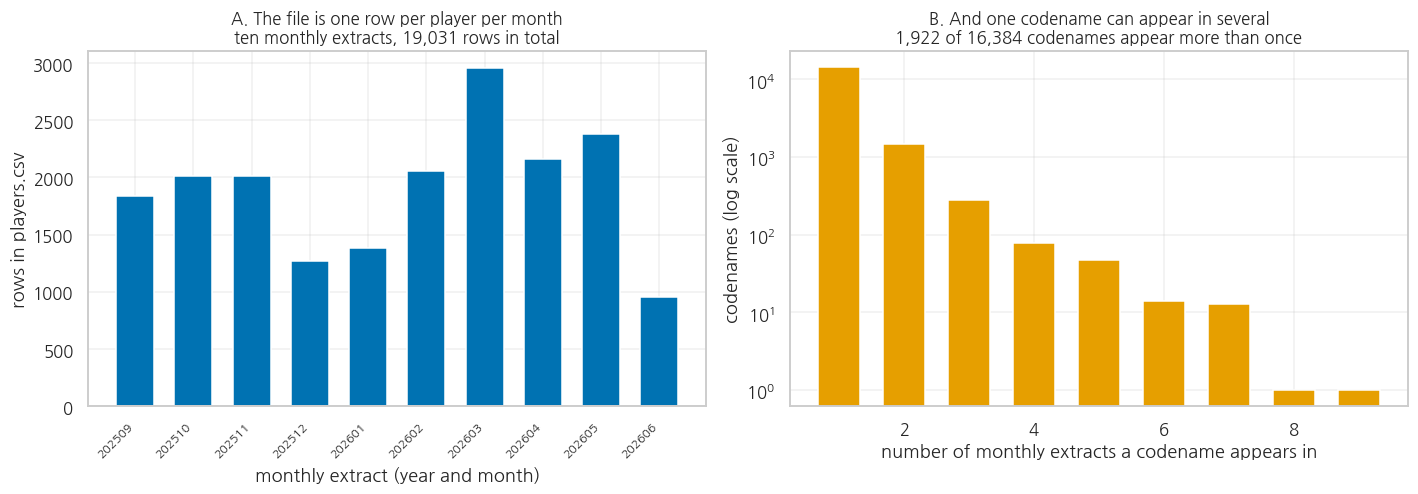

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

ax = axes[0]
per_month = players.groupby('month').size()
short = [m.replace('AQUALAB_', '')[:6] for m in per_month.index]
ax.bar(np.arange(len(per_month)), per_month.to_numpy(), 0.65, color=BLUE)
ax.set_xticks(np.arange(len(per_month)))
ax.set_xticklabels(short, rotation=45, ha='right', fontsize=8)
ax.set_xlabel('monthly extract (year and month)')
ax.set_ylabel('rows in players.csv')
ax.set_title('A. The file is one row per player per month\n'
             'ten monthly extracts, %s rows in total' % format(len(players), ','))

ax = axes[1]
spread = months_per_name.value_counts().sort_index()
ax.bar(spread.index.to_numpy(), spread.to_numpy(), 0.65, color=ORANGE)
ax.set_yscale('log')
ax.set_xlabel('number of monthly extracts a codename appears in')
ax.set_ylabel('codenames (log scale)')
ax.set_title('B. And one codename can appear in several\n'
             '%s of %s codenames appear more than once'
             % (format(int((months_per_name > 1).sum()), ','),
                format(players['PlayerID'].nunique(), ',')))

fig.tight_layout()
plt.show()

**Let's look at the output.** Two panels, and a question each.

1. Panel A is not flat: March 2026 supplies about three times as many rows as June 2026. What are
   some plausible explanations for that shape? It may be useful to work through the ones about
   **schools** before the ones about children.
2. Panel B shows that 1,922 codenames appear in more than one month. Suppose they are all the same
   children returning; then suppose none of them are. Which number in this notebook would change,
   and in which direction?
3. Treating the **player-month** as the unit of analysis is a decision we are making rather than
   one the file makes for us. What does it cost? If one child played across four months, how many
   times do they appear in every average computed below, and what would you want to say about that
   in a methods section?

Question 3 is the reason every interval in this notebook resamples **codenames** rather than rows.
A row is not an independent observation when 617 rows come from 508 people, and you will see that
machinery in section 4.

*Connecting to the readings.* Reardon, Kumar and Revelle (2022) present game telemetry as valuable
for the density and grain of what it records. The grain is real here, and so is a prior question
their chapter keeps in view: what a row is, and whether the identifier attached to it is a person.
A shared classroom device makes that question harder rather than easier.

## 2. What is wrong with the raw files

Every dataset in this course has arrived with mess in it, and you have met a different kind each
week: a blank socioeconomic band, a byte order mark, a clock that counts in whole minutes. This
one arrives as a pipeline dumps it, and the mess is mostly in the columns rather than in the rows.

The first check below is among the cheapest in data analysis and is easy to skip: **how many
different values does each column actually hold?** A column with one value cannot tell you
anything, whatever its name promises.

**Run the cell below.** Then we will read what it finds, the decisions that follow, and what those
decisions cost.

In [4]:
print("HOW MANY DIFFERENT VALUES DOES EACH COLUMN OF player_jobs ACTUALLY HOLD?")
for col in jobs_raw.columns:
    n = jobs_raw[col].nunique()
    flag = "   <-- one value only. This column can tell you nothing." if n == 1 else ""
    print("   %-14s %7d%s" % (col, n, flag))

diff_cols = [c for c in players.columns if c.startswith('diff')]
print()
print("The five 'JobTriesInArgumentPerDifficulty' columns in players.csv:")
print("   all five are zero in all %s rows: %s"
      % (format(len(players), ','),
         bool(all((players[c] == 0).all() for c in diff_cols))))

print()
print("THE JOB THAT IS NOT A JOB")
print("   rows labelled 'no-active-job': %s (%.1f%% of the file)"
      % (format(int((jobs_raw['job'] == 'no-active-job').sum()), ','),
         100 * (jobs_raw['job'] == 'no-active-job').mean()))

print()
print("ROWS WITH NO PLAYER IN THEM")
missing = players[players['PlayerID'].isna()]
print("   player-months with no codename at all: %d" % len(missing))
print("   their SessionCount runs from %d to %d, and every one of them has"
      % (missing['SessionCount'].min(), missing['SessionCount'].max()))
print("   %d jobs completed." % missing['JobsCompleted-UniqueCount'].max())

print()
print("WHO WAS PLAYING, AND WHO WAS TESTING")
print(players['ExperimentalCondition'].value_counts(dropna=False).to_string())

print()
print("DURATIONS THAT RUN BACKWARDS")
time_cols = ['TotalArgumentationTime-Seconds', 'TotalDiveTime-Seconds',
             'TotalExperimentationTime-Seconds', 'TotalModelingTime-Seconds']
neg = (players[time_cols] < 0).any(axis=1)
print("   player-months with at least one negative duration: %s" % format(int(neg.sum()), ','))
print("   most negative value recorded: %s seconds"
      % format(int(players[time_cols].min().min()), ','))

print()
print("TWO LANGUAGES IN ONE COLUMN")
print(players['aff0_AffectItemResponses'].value_counts().to_string())

HOW MANY DIFFERENT VALUES DOES EACH COLUMN OF player_jobs ACTUALLY HOLD?
   month               10
   PlayerID         13672
   job                 54
   attempted            1   <-- one value only. This column can tell you nothing.
   argfails            78
   tries              169
   tasks               55
   help                60
   divetime         20837
   argtime              1   <-- one value only. This column can tell you nothing.
   priorcomplete    31160

The five 'JobTriesInArgumentPerDifficulty' columns in players.csv:
   all five are zero in all 19,031 rows: True

THE JOB THAT IS NOT A JOB
   rows labelled 'no-active-job': 10,340 (10.7% of the file)

ROWS WITH NO PLAYER IN THEM
   player-months with no codename at all: 10
   their SessionCount runs from 187 to 486, and every one of them has
   0 jobs completed.

WHO WAS PLAYING, AND WHO WAS TESTING
ExperimentalCondition
production                                              9610
production-no-failure-prediction-original

Each finding below is somebody's decision waiting to happen.

1. **`attempted` holds one value.** Every row says `True`. The column was presumably meant to distinguish attempted from not-attempted jobs, but the extract only contains attempted jobs, so the column is a constant. That is harmless, and it is a useful reminder that a column's name promises something the measurement may not deliver.
2. **`argtime` holds one value too**, and that value is `0:00:00`, in all 96,322 rows. The timer never recorded. If you had built an analysis on argumentation *time* you would have built it on nothing, and the column name would not have warned you.
3. **The five `JobTriesInArgumentPerDifficulty` columns are zero everywhere.** Five of the 145 features in `players.csv` are empty. That is a feature that shipped before its logging did.
4. **`no-active-job` is not a job.** It is the category for time the game could not attach to any job: 10,340 rows, 10.7 percent of the file. Left in, it becomes the second most common "job" in AQUALAB and it contaminates every per-job average.
5. **Ten rows have no player.** One per monthly extract, each with hundreds of sessions and zero jobs completed. These are the monthly leftovers: activity the pipeline could not attribute to anybody. They are not children.
6. **`ExperimentalCondition` has thirteen values**, and only four of them start with `production`. The rest are `develop`, `staging`, `data-scripting`, two condition strings that lost their prefix entirely (three rows between them), and nineteen blanks. Some of the play in this file is a developer testing a build.
7. **Durations run backwards.** 2,631 player-months carry at least one negative duration, and the worst is about minus 3.27 million seconds, which is minus thirty-eight days. Clocks in telemetry are hard: a device sleeps, a timestamp resets, a session spans midnight, and a subtraction goes the wrong way.
8. **The affect column is bilingual.** `Feliz`, `Concentrado(a)`, `Aburrido(a)`, `Frustrado(a)`. The game was played in Spanish by some children and the extract keeps their answers in the language they were given. Group by the raw string and those children silently become their own categories, each too small to see.

The decisions follow. Notice that all three are **exclusions**, and every exclusion is a small act of definition about who counts.

In [5]:
# ---------------------------------------------------------------- decisions
is_production = players['ExperimentalCondition'].astype(str).str.startswith('production')
play = players[is_production].copy()

jobs = jobs_raw[jobs_raw['job'] != 'no-active-job'].copy()


def count_prior(cell):
    """priorcomplete is a text list of the jobs finished before this one started."""
    return len(json.loads(cell)) if isinstance(cell, str) else 0


jobs['completed_before'] = jobs['priorcomplete'].apply(count_prior)

KEY = ['month', 'PlayerID']
jobs = jobs.merge(play[KEY + ['JobsCompleted-UniqueCount', 'TotalPlayerTime-Seconds',
                              'SessionCount']], on=KEY, how='inner')

print("DECISION 1  keep only production play")
print("   %6s player-months in  ->  %6s out   (%d removed)"
      % (format(len(players), ','), format(len(play), ','), len(players) - len(play)))
print("DECISION 2  drop the 'no-active-job' pseudo-category")
print("   %6s job rows in       ->  %6s out   (%s removed)"
      % (format(len(jobs_raw), ','),
         format(int((jobs_raw['job'] != 'no-active-job').sum()), ','),
         format(int((jobs_raw['job'] == 'no-active-job').sum()), ',')))
print("DECISION 3  keep only job rows whose player-month survived decision 1")
print("   %6s job rows in       ->  %6s out   (%d removed)"
      % (format(int((jobs_raw['job'] != 'no-active-job').sum()), ','),
         format(len(jobs), ','),
         int((jobs_raw['job'] != 'no-active-job').sum()) - len(jobs)))
print()
print("Working tables: %s player-months, %s job rows, %d distinct jobs."
      % (format(len(play), ','), format(len(jobs), ','), jobs['job'].nunique()))

# ------------------------------------------------- and one check we can run
# 'completed_before' comes from a text list. Does it agree with the month total?
check = jobs_raw.copy()
check['completed_before'] = check['priorcomplete'].apply(count_prior)
check = check.merge(play[KEY + ['JobsCompleted-UniqueCount']], on=KEY, how='inner')
deepest = check.groupby(KEY)['completed_before'].max()
month_total = check.groupby(KEY)['JobsCompleted-UniqueCount'].first()
print()
print("Consistency check: in %.1f%% of player-months, the largest 'completed before'"
      % (100 * (deepest == month_total).mean()))
print("count equals that month's total jobs completed. The two columns share a clock,")
print("which is what makes the ordering in section 4 possible.")

DECISION 1  keep only production play
   19,031 player-months in  ->  18,959 out   (72 removed)
DECISION 2  drop the 'no-active-job' pseudo-category
   96,322 job rows in       ->  85,982 out   (10,340 removed)
DECISION 3  keep only job rows whose player-month survived decision 1
   85,982 job rows in       ->  85,903 out   (79 removed)

Working tables: 18,959 player-months, 85,903 job rows, 53 distinct jobs.



Consistency check: in 100.0% of player-months, the largest 'completed before'
count equals that month's total jobs completed. The two columns share a clock,
which is what makes the ordering in section 4 possible.


**What the decisions cost.**

| Decision | Removed | What it costs |
|---|---|---|
| Keep only `production` | 72 player-months | Ten of those were the unattributed monthly leftovers, which should go. The rest were developers and staging builds, which should also go. But `develop` rows might include a classroom on a pre-release build, and we cannot tell. We lose 0.4 percent of the file and buy the right to say "these rows are play." |
| Drop `no-active-job` | 10,340 job rows | We lose a real and interesting behaviour: wandering the game with nothing taken on. If your question were "what do children do when they have not chosen a task", this decision would delete your entire dataset. Ours is not, so it goes. |
| Keep jobs whose player-month survived | 79 job rows | Trivial in size. It matters because it makes the two tables agree about who exists, and disagreements between tables are where silent errors live. |

**What we did *not* do, and why.**

We did **not** drop the 2,631 player-months with negative durations. Nothing in this notebook uses
those four columns, and dropping 14 percent of the file to fix a variable we never touch would
cost more than the problem does. If you build on the duration columns in your own work, that
decision comes back and you will need a rule: clamp at zero, treat as missing, or exclude. Each of
those is defensible and each of them changes the answer.

We did **not** merge the Spanish and English feeling words yet. That happens in section 5, where
the words are actually used, and it happens in view.

**Let's discuss.**

1. Decision 2 removes 10.7 percent of the job rows. If you reported this analysis in a paper,
   where would that number appear, and what would a reader be entitled to conclude if it appeared
   nowhere?
2. `argtime` is a column of zeros with a plausible name. What one sentence would you add to a
   methods section about it? And how might you have discovered it without running the
   distinct-values check?
3. The ten rows with no codename have hundreds of sessions each. Somebody could have written "the
   most active players in AQUALAB average 300 sessions a month." What is wrong with that claim,
   and which check catches it?

## 3. The hardest job in the game

AQUALAB's structure is: take a job, gather evidence, then **argue** for a conclusion. The argument
step is where the science is, and the extract counts it. The `tries` column holds how many
argumentation attempts the game logged for that player on that job.

So: which job asks the most of a child?

**Run the cell below.** It puts two summaries of the same column side by side, and they disagree.

In [6]:
by_job = jobs.groupby('job').agg(
    players=('tries', 'size'),
    mean_tries=('tries', 'mean'),
    median_tries=('tries', 'median'),
    max_tries=('tries', 'max'),
)
common = by_job[by_job['players'] >= 300].sort_values('mean_tries', ascending=False)

print("Jobs attempted by at least 300 player-months, hardest argument first:")
print(common.head(8).round(2).to_string())
print()
print("Median of the per-job medians: %.1f tries." % common['median_tries'].median())

SPIKE = 'coral-hunting-lions'
spike = jobs[jobs['job'] == SPIKE].copy()

print()
print("=== %s ===" % SPIKE)
print("player-months attempting it : %d" % len(spike))
print("distinct codenames          : %d" % spike['PlayerID'].nunique())
print("mean tries                  : %.2f" % spike['tries'].mean())
print("median tries                : %.1f" % spike['tries'].median())
print("standard deviation          : %.1f" % spike['tries'].std())
print("largest single value        : %d" % spike['tries'].max())
print("share who logged zero tries : %.1f%%" % (100 * (spike['tries'] == 0).mean()))
top5 = int(round(0.05 * len(spike)))
print("the busiest %d player-months (5%%) account for %.1f%% of every try on this job"
      % (top5, 100 * spike['tries'].nlargest(top5).sum() / spike['tries'].sum()))

Jobs attempted by at least 300 player-months, hardest argument first:
                           players  mean_tries  median_tries  max_tries
job                                                                    
coral-hunting-lions            617       31.98           8.0        370
bayou-shrimp-tastrophe         341       24.55          15.0        316
coral-stressed                1587       14.91           8.0        230
kelp-refuge-failure            809       12.72           7.0        123
coral-much-algae               637       11.50           6.0        156
arctic-isolated-instance       610        9.61           6.0        126
arctic-salmon-competition      521        9.28           6.0         83
arctic-cause-of-death          735        8.91           3.0        160

Median of the per-job medians: 1.0 tries.

=== coral-hunting-lions ===
player-months attempting it : 617
distinct codenames          : 508
mean tries                  : 31.98
median tries                : 8.0


**Let's look at the output.** `coral-hunting-lions` averages **31.98** argumentation tries against
a median of **8**. The typical job in this game has a median of **1**.

A mean four times the median comes from a distribution where a few observations carry most of the
total, which is a situation in which the word "average" needs care.

**Run the cell below** to draw it.

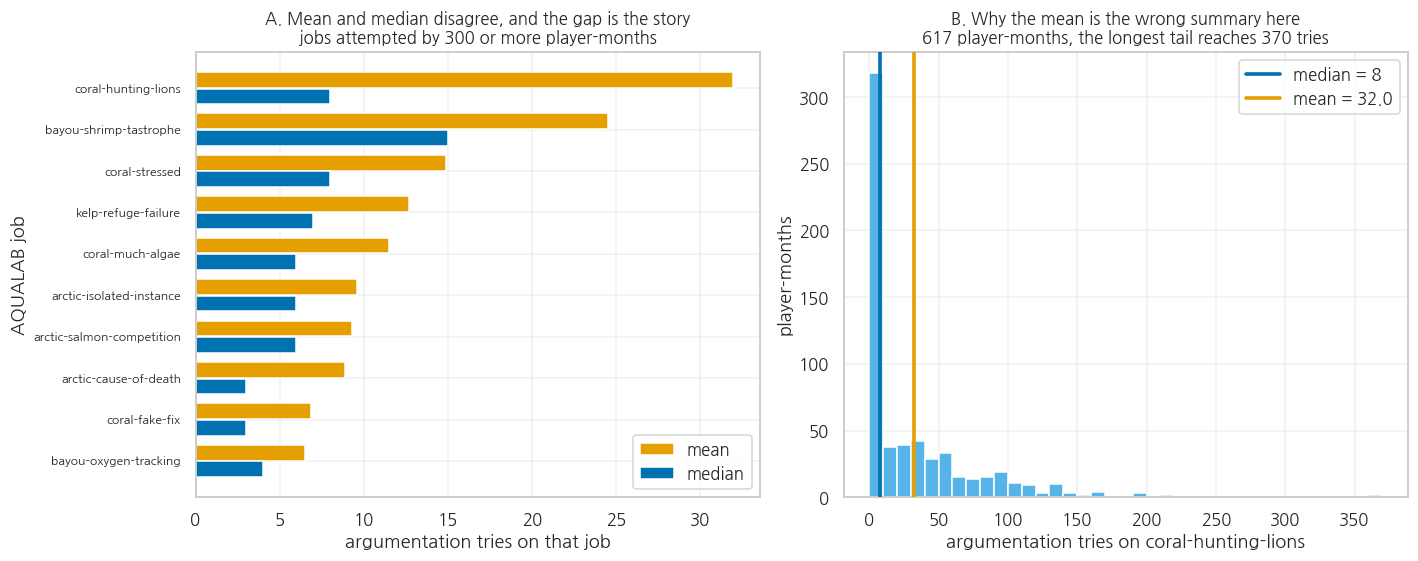

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.2))

ax = axes[0]
top = common.head(10).iloc[::-1]
y = np.arange(len(top))
ax.barh(y + 0.20, top['mean_tries'], height=0.38, color=ORANGE, label='mean')
ax.barh(y - 0.20, top['median_tries'], height=0.38, color=BLUE, label='median')
ax.set_yticks(y)
ax.set_yticklabels(top.index, fontsize=8)
ax.set_xlabel('argumentation tries on that job')
ax.set_ylabel('AQUALAB job')
ax.set_title('A. Mean and median disagree, and the gap is the story\n'
             'jobs attempted by 300 or more player-months')
ax.legend(loc='lower right')

ax = axes[1]
ax.hist(spike['tries'], bins=np.arange(0, 380, 10), color=SKY, edgecolor='white')
ax.axvline(spike['tries'].median(), color=BLUE, lw=2.4, zorder=5,
           label='median = %.0f' % spike['tries'].median())
ax.axvline(spike['tries'].mean(), color=ORANGE, lw=2.4, zorder=5,
           label='mean = %.1f' % spike['tries'].mean())
ax.set_xlabel('argumentation tries on coral-hunting-lions')
ax.set_ylabel('player-months')
ax.set_title('B. Why the mean is the wrong summary here\n'
             '%d player-months, the longest tail reaches %d tries'
             % (len(spike), spike['tries'].max()))
ax.legend()

fig.tight_layout()
plt.show()

**Let's discuss.**

1. The mean is 31.98 and the median is 8. What does each of them miss about "how hard is this
   job?" What would you report instead, and notice whether your answer has more than one number in
   it.
2. 42.3 percent of the player-months that took this job logged **zero** argumentation tries. What
   are some plausible realities that would produce a zero here? It may be useful to include some
   about the game or the logging alongside any about the child.
3. The busiest 5 percent supply 29.1 percent of all the tries on this job. If you were the
   designer of AQUALAB and somebody showed you only the mean, what would you change about the
   game? Having seen panel B, is that still what you would change?
4. A harder methods question. Panel A ranks jobs by mean tries. Ranked by median,
   `bayou-shrimp-tastrophe` (median 15) would sit above `coral-hunting-lions` (median 8). Which
   ranking would you publish, and what would publishing both look like?

It may help to keep three things separate here, as we did in Week 1:

| | |
|---|---|
| **What the data directly show** | 617 player-months attempted this job; their tries have a mean of 31.98, a median of 8, and a maximum of 370; 42.3 percent logged zero |
| **A plausible interpretation** | The distribution is concentrated because voluntary play is concentrated, with a few children arguing a great deal |
| **What this file cannot establish** | Whether a zero means a child skipped the argument step, the game did not offer it, or the logging missed it, since nothing in the extract records which |

### Your turn 1

Skew is not a property of this one job. Point the same three summaries at another one and see.

`YOUR_JOB` is set to `'coral-stressed'`, which runs as it stands. Try `'bayou-shrimp-tastrophe'` (the highest median in the game), `'kelp-welcome'` (the one nearly everybody plays), or any job name from the table above.

In [8]:
# TODO: change this to another job name and rerun.
YOUR_JOB = 'coral-stressed'      # working default: the notebook runs as is

sel = jobs[jobs['job'] == YOUR_JOB]
if len(sel) < 30:
    print("Only %d player-months attempted '%s'. Pick a busier job from the table."
          % (len(sel), YOUR_JOB))
else:
    top5_n = max(1, int(round(0.05 * len(sel))))
    print("%s" % YOUR_JOB)
    print("   player-months %d, distinct codenames %d" % (len(sel), sel['PlayerID'].nunique()))
    print("   mean %.2f tries, median %.1f, most %d"
          % (sel['tries'].mean(), sel['tries'].median(), sel['tries'].max()))
    print("   mean divided by median: %.1f"
          % (sel['tries'].mean() / max(sel['tries'].median(), 0.5)))
    print("   the busiest 5%% of player-months supply %.1f%% of all the tries"
          % (100 * sel['tries'].nlargest(top5_n).sum() / max(sel['tries'].sum(), 1)))

coral-stressed
   player-months 1587, distinct codenames 1500
   mean 14.91 tries, median 8.0, most 230
   mean divided by median: 1.9
   the busiest 5% of player-months supply 26.6% of all the tries


**Let's discuss.** One pattern worth noticing across jobs is how much of a job's total the busiest
5 percent of player-months supply. What are some plausible explanations for that concentration? Is
`coral-hunting-lions` special, or is count data from voluntary play like this more generally? What
sentence would you use to warn a reader about means in a game telemetry paper, and can you make it
a sentence about the measurement rather than about the players?

## 4. Did persisting pay?

Here is the result the field wants. Among the children who took on the hardest job in AQUALAB, did
the ones who kept arguing go on to finish more of the game?

Before any code, one problem is worth having in view, because the rest of the section turns on it.

> **Argumentation tries** is a count of activity. **Jobs completed** is a count of activity. A
> child who is still playing accumulates both. A child who stops accumulates neither. So *some*
> association between them follows from arithmetic alone.

One more thing before the code. We are about to put children into a group called "persisted". That
word names **a number in a log**: more than ten argumentation attempts on one job. It does not name
a kind of child, it does not travel outside this job, and the moment it leaves this notebook
somebody may read it as a personality. The section takes the word apart.

Separate the selection question from the effect question:

- **The selection question.** Who ends up in the "persisted" group? What kind of player-month is
  that?
- **The effect question.** Given two children who were both still there, did the one who kept
  trying finish more?

Many "productive struggle" claims in this literature answer the first while sounding like they
answered the second. We are going to answer them separately.

**Run the cell below.** It defines two tools, and the comments in it are worth reading.

In [9]:
def cluster_bootstrap_gap(frame, value_col, flag_col, cluster_col,
                          n_boot=2000, seed=SEED):
    """A 95% interval for a difference in means, resampling whole people.

    Rows here are player-months, and one codename can supply several of them.
    Resampling ROWS would pretend those rows were independent of each other,
    which would make the interval too narrow and the result look surer than it
    is. Resampling CODENAMES, and taking all of that codename's rows each time,
    keeps the nesting intact. This is the standard fix when rows sit inside
    people, essays, groups, or sessions."""
    rng = np.random.default_rng(seed)
    codes, names = pd.factorize(frame[cluster_col])
    rows_for = [np.flatnonzero(codes == i) for i in range(len(names))]
    y = frame[value_col].to_numpy(dtype=float)
    g = frame[flag_col].to_numpy(dtype=bool)
    observed = y[g].mean() - y[~g].mean()
    draws = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(names), len(names))
        rows = np.concatenate([rows_for[i] for i in pick])
        yy, gg = y[rows], g[rows]
        if gg.any() and (~gg).any():
            draws.append(yy[gg].mean() - yy[~gg].mean())
    draws = np.array(draws)
    return observed, np.percentile(draws, 2.5), np.percentile(draws, 97.5)


def prob_higher(x, y):
    """P(a value drawn from x is above a value drawn from y), ties counted half.

    A rank statistic. One player-month with 370 tries cannot move it, which
    matters a great deal in a distribution like the one you just drew. 0.50
    means the two groups are completely interleaved; 1.00 means every value in
    x is above every value in y. It also has the pleasant property of being
    comparable across two games that measure completely different things."""
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    ranks = pd.Series(np.concatenate([x, y])).rank().to_numpy()
    rank_sum_x = ranks[:len(x)].sum()
    return (rank_sum_x - len(x) * (len(x) + 1) / 2) / (len(x) * len(y))


def spearman(a, b):
    """Correlation of the ranks, safe on the skewed counts we have here."""
    return float(np.corrcoef(pd.Series(a).rank(), pd.Series(b).rank())[0, 1])


print("Three tools defined: a cluster bootstrap, a rank-based effect size,")
print("and a rank correlation. Nothing imported to get them.")

Three tools defined: a cluster bootstrap, a rank-based effect size,
and a rank correlation. Nothing imported to get them.


Now the comparison. The threshold, "more than ten tries", is **our** choice and nothing in the
data suggested it. You will move it in Your turn 2.

The one genuinely clever thing available here is the `priorcomplete` column. It lists the jobs a
child had already finished **before starting this one**, which means we can split that month's
total into what happened *before* the hard job and what happened *after* it. That is a real
temporal ordering inside a file that otherwise has none, and the consistency check in section 2 is
what licenses us to use it.

**Run the cell below.**

In [10]:
deepest_in_month = jobs.groupby(KEY)['completed_before'].max().rename('deepest_before')

spike = jobs[jobs['job'] == SPIKE].merge(deepest_in_month, on=KEY, how='left')
spike['completed_after'] = spike['JobsCompleted-UniqueCount'] - spike['completed_before']
# Read this definition carefully, because the section turns on it and the obvious
# reading of it is wrong. 'deepest_before' is the largest "jobs completed before
# this one started" anywhere in that player-month. So the flag below is true when
# SOME LATER JOB ROW STARTED AFTER AT LEAST ONE MORE JOB HAD BEEN COMPLETED.
#
# That is not the same as "the child attempted another job". A child who took
# three more jobs and finished none of them leaves every one of those rows sitting
# at the same 'completed_before', and this file has no timestamps on job rows, so
# nothing can order them. The flag is therefore "at least one further job was
# COMPLETED after this one began", which is a lower bound on continued play, and
# it is very nearly the outcome itself. The next cell measures how nearly.
spike['finished_more_after'] = spike['deepest_before'] > spike['completed_before']
spike['persisted'] = spike['tries'] > 10

summary = spike.groupby('persisted').agg(
    player_months=('tries', 'size'),
    codenames=('PlayerID', 'nunique'),
    mean_tries=('tries', 'mean'),
    completed_before=('completed_before', 'mean'),
    completed_after=('completed_after', 'mean'),
    completed_total=('JobsCompleted-UniqueCount', 'mean'),
)
summary.index = ['10 tries or fewer', 'more than 10 tries']
print(summary.round(2).to_string())
print()

for label, col in [('total jobs completed that month', 'JobsCompleted-UniqueCount'),
                   ('completed BEFORE this job     ', 'completed_before'),
                   ('completed AFTER this job      ', 'completed_after')]:
    gap, low, high = cluster_bootstrap_gap(spike, col, 'persisted', 'PlayerID')
    print("%s  gap %+6.2f   95%% interval [%+.2f, %+.2f]" % (label, gap, low, high))

                    player_months  codenames  mean_tries  completed_before  completed_after  completed_total
10 tries or fewer             319        258        0.79             17.41             0.55            17.96
more than 10 tries            298        284       65.38             20.93            11.84            32.76



total jobs completed that month  gap +14.81   95% interval [+12.24, +17.24]


completed BEFORE this job       gap  +3.52   95% interval [+1.12, +5.90]


completed AFTER this job        gap +11.29   95% interval [+9.67, +12.91]


**Let's look at the output.** The gap is large. Children who kept arguing at this job completed
**32.76** jobs that month against **17.96**, a gap of **+14.81** with an interval from **+12.24 to
+17.24**. That interval was built by resampling the 508 codenames rather than the 617 rows, so it
already accounts for the same child appearing more than once.

Now split the gap in time. Only **+3.52** of it [+1.12, +5.90] was already accumulated *before* the
hard job. **+11.29** of it [+9.67, +12.91] came *after*. One reading is that persisting at the hard
job changed what the child did next.

Before settling on that, it is worth asking the boring question. **Was the child still there?**

**Run the cell below.**

In [11]:
print("Did any further job get COMPLETED after this one began?")
cont = spike.groupby('persisted')['finished_more_after'].agg(['size', 'mean'])
cont.index = ['10 tries or fewer', 'more than 10 tries']
for label, row in cont.iterrows():
    print("   %-19s %3d player-months, %5.1f%% completed at least one more job"
          % (label, row['size'], 100 * row['mean']))

all_jobs = jobs.merge(deepest_in_month, on=KEY, how='left')
print()
print("For comparison, across all %s job rows in AQUALAB, %.1f%% have no further job"
      % (format(len(all_jobs), ','),
         100 * (all_jobs['completed_before'] >= all_jobs['deepest_before']).mean()))
print("completed after them. For coral-hunting-lions the figure is %.1f%%."
      % (100 * (~spike['finished_more_after']).mean()))

print()
print("AND THE LIMIT OF THAT FLAG, MEASURED RATHER THAN ASSUMED")
same_level = []
for _, rr in spike.iterrows():
    d = jobs[(jobs['month'] == rr['month']) & (jobs['PlayerID'] == rr['PlayerID'])]
    same_level.append(int((d['completed_before'] == rr['completed_before']).sum() - 1))
spike['other_rows_same_depth'] = same_level
stopped = spike[~spike['finished_more_after']]
print("   Of the %d player-months the flag calls 'no further completion', %.0f%% took at"
      % (len(stopped), 100 * (stopped['other_rows_same_depth'] > 0).mean()))
print("   least one OTHER job at the same completion depth, so they attempted more and")
print("   finished nothing more. The file cannot order those rows, so it cannot say")
print("   whether that happened before or after this job.")
print("   The flag is a lower bound on continued play, and it agrees with")
print("   'completed_after > 0' on %d of the %d rows."
      % (int((spike['finished_more_after'] == (spike['completed_after'] > 0)).sum()), len(spike)))
print("   Treat panel B as a decomposition of the outcome, not as an independent check")
print("   on whether a child was still playing. This file cannot see that.")

print()
print("Rank correlation between tries on this job and ...")
print("   ... jobs completed afterwards           rho = %+.3f"
      % spearman(spike['tries'], spike['completed_after']))
print("   ... whether ANY further job was completed rho = %+.3f"
      % spearman(spike['tries'], spike['finished_more_after'].astype(int)))

print()
still = spike[spike['finished_more_after']].copy()
print("AMONG THE %d PLAYER-MONTHS THAT COMPLETED AT LEAST ONE MORE JOB (%d codenames)"
      % (len(still), still['PlayerID'].nunique()))
print("   rank correlation, tries and jobs completed afterwards: rho = %+.3f"
      % spearman(still['tries'], still['completed_after']))

still['tries_quartile'] = pd.qcut(still['tries'], 4)
q = still.groupby('tries_quartile', observed=True)['completed_after'].agg(
    ['size', 'mean', 'median'])
print(q.round(2).to_string())

gap_still, lo_still, hi_still = cluster_bootstrap_gap(
    still, 'completed_after', 'persisted', 'PlayerID')
print()
print("   gap between the two persistence groups here: %+.2f  [%+.2f, %+.2f]"
      % (gap_still, lo_still, hi_still))
print("   with only %d and %d player-months on the two sides, that interval is"
      % ((~still['persisted']).sum(), still['persisted'].sum()))
print("   wide on purpose and cannot rule out a moderate effect.")

Did any further job get COMPLETED after this one began?
   10 tries or fewer   319 player-months,   3.1% completed at least one more job
   more than 10 tries  298 player-months,  67.1% completed at least one more job

For comparison, across all 85,903 job rows in AQUALAB, 21.9% have no further job
completed after them. For coral-hunting-lions the figure is 66.0%.

AND THE LIMIT OF THAT FLAG, MEASURED RATHER THAN ASSUMED


   Of the 407 player-months the flag calls 'no further completion', 64% took at
   least one OTHER job at the same completion depth, so they attempted more and
   finished nothing more. The file cannot order those rows, so it cannot say
   whether that happened before or after this job.
   The flag is a lower bound on continued play, and it agrees with
   'completed_after > 0' on 607 of the 617 rows.
   Treat panel B as a decomposition of the outcome, not as an independent check
   on whether a child was still playing. This file cannot see that.

Rank correlation between tries on this job and ...
   ... jobs completed afterwards           rho = +0.654
   ... whether ANY further job was completed rho = +0.649

AMONG THE 210 PLAYER-MONTHS THAT COMPLETED AT LEAST ONE MORE JOB (208 codenames)
   rank correlation, tries and jobs completed afterwards: rho = -0.007
                size   mean  median
tries_quartile                     
(6.999, 28.0]     54  17.22    14.0
(28.0, 49.0]      53 

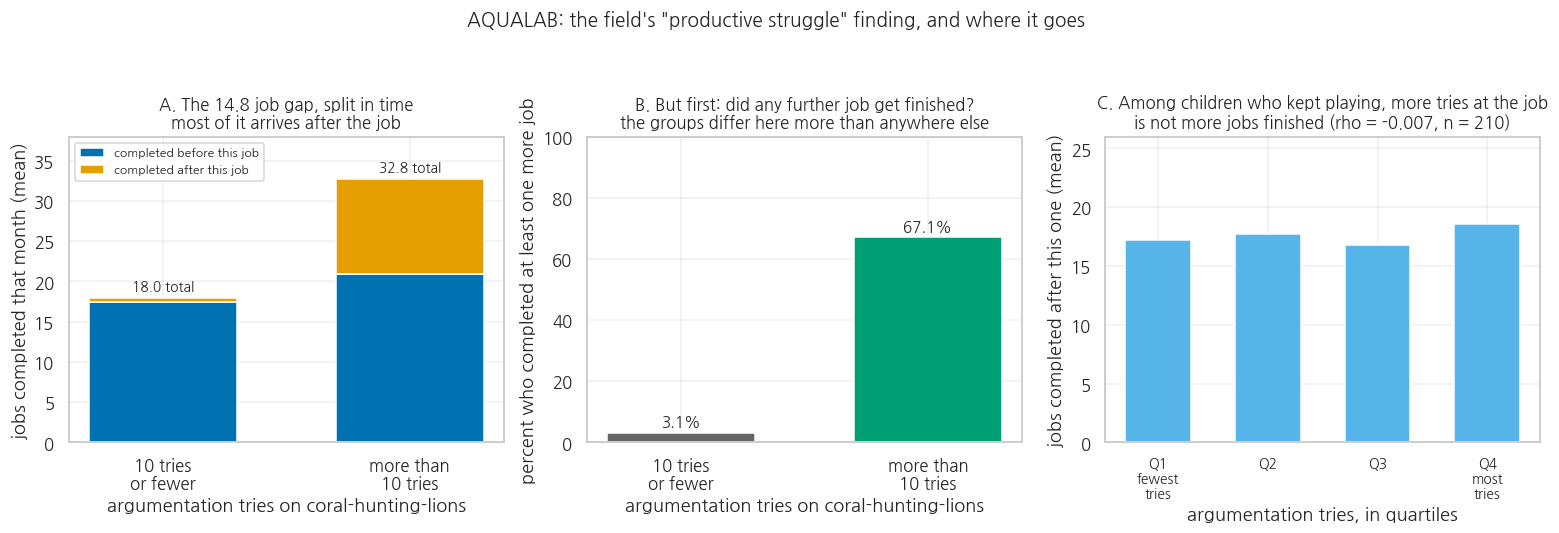

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14.2, 4.9))
labels = ['10 tries\nor fewer', 'more than\n10 tries']
x = np.arange(2)

ax = axes[0]
before = [spike.loc[~spike['persisted'], 'completed_before'].mean(),
          spike.loc[spike['persisted'], 'completed_before'].mean()]
after = [spike.loc[~spike['persisted'], 'completed_after'].mean(),
         spike.loc[spike['persisted'], 'completed_after'].mean()]
ax.bar(x, before, 0.6, color=BLUE, label='completed before this job')
ax.bar(x, after, 0.6, bottom=before, color=ORANGE, label='completed after this job')
for i in range(2):
    ax.text(i, before[i] + after[i] + 0.9, '%.1f total' % (before[i] + after[i]),
            ha='center', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('argumentation tries on coral-hunting-lions')
ax.set_ylabel('jobs completed that month (mean)')
ax.set_ylim(0, 38)
ax.set_title('A. The 14.8 job gap, split in time\nmost of it arrives after the job')
ax.legend(fontsize=8, loc='upper left')

ax = axes[1]
share = [100 * spike.loc[~spike['persisted'], 'finished_more_after'].mean(),
         100 * spike.loc[spike['persisted'], 'finished_more_after'].mean()]
ax.bar(x, share, 0.6, color=[GREY, GREEN])
for i in range(2):
    ax.text(i, share[i] + 2.0, '%.1f%%' % share[i], ha='center', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel('argumentation tries on coral-hunting-lions')
ax.set_ylabel('percent who completed at least one more job')
ax.set_ylim(0, 100)
ax.set_title('B. But first: did any further job get finished?\nthe groups differ here more than anywhere else')

ax = axes[2]
qm = q['mean'].to_numpy()
ax.bar(np.arange(len(qm)), qm, 0.6, color=SKY)
ax.set_xticks(np.arange(len(qm)))
ax.set_xticklabels(['Q1\nfewest\ntries', 'Q2', 'Q3', 'Q4\nmost\ntries'], fontsize=9)
ax.set_xlabel('argumentation tries, in quartiles')
ax.set_ylabel('jobs completed after this one (mean)')
ax.set_ylim(0, 26)
ax.set_title('C. Among children who kept playing, more tries at the job\nis not more jobs finished (rho = %+.3f, n = %d)'
             % (spearman(still['tries'], still['completed_after']), len(still)))

fig.suptitle('AQUALAB: the field\'s "productive struggle" finding, and where it goes',
             fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

**Let's look at the output.** The three panels are worth reading in order.

**Panel B** matters most here, and the first job is to say exactly what it measures. **67.1
percent** of the player-months that argued more than ten times went on to complete at least one
further job that month; **3.1 percent** of the others did. The rank correlation between tries and
that flag is **+0.649**, and the rank correlation between tries and jobs completed afterwards is
**+0.654**. Those two numbers are nearly identical because the flag and the outcome are nearly the
same variable: they agree on 607 of the 617 rows.

So panel B is not an independent check on whether a child was still playing. It is the outcome
split into "any further completion at all" and "how many, given some", which is a useful
decomposition and a different thing. The file does not support the stronger version: 64 percent of
the player-months the flag calls "no further completion" took other jobs at the same completion
depth, so they attempted more and finished nothing more, and with no timestamps on job rows
nothing can say whether those attempts came before or after this one.

**Panel C** is the test. Among the **210** player-months that demonstrably kept playing, the rank
correlation between tries on this job and jobs completed afterwards is **-0.007**. The four
quartiles average 17.22, 17.75, 16.81 and 18.55 jobs afterwards, which is flat.

A statement the file supports would read something like this:

> Among player-months that attempted AQUALAB's hardest argument, arguing more than ten times was
> associated with completing 14.81 more jobs that month, interval [12.24, 17.24]. Almost all of
> that association is carried by whether any further job was completed at all: 67.1 percent
> against 3.1 percent. Among the player-months where one was, argumentation tries and later
> completions are uncorrelated (rho = -0.007, n = 210). We find no evidence here that persisting
> at this job produced further progress, and with 10 player-months on one side of that comparison
> we cannot rule out a modest effect. The record cannot distinguish a child who stopped playing
> from a child who kept attempting jobs and finished none.

One more number belongs beside that. No further job is completed after `coral-hunting-lions` in
66.0 percent of the player-months that reach it, against 21.9 percent across all job rows in the
game. Something ends there, and that is a question about the design rather than about children.
"Ends" here means that the completions stop, not that the child left.

**Keeping three things apart.**

| | |
|---|---|
| **What the data directly show** | A gap of +14.81 jobs [+12.24, +17.24]; 67.1 percent against 3.1 percent on the further-completion flag; rho = -0.007 among the 210 player-months with a further completion |
| **A plausible interpretation** | The raw gap is mostly a difference in whether the record continued at all, rather than a return to persisting at this job |
| **What this file cannot establish** | Whether a record that stops means a child stopped playing. The extract has no timestamps on job rows, no enrolment or attendance field, and a hard month boundary, so a child who left and a child who kept attempting and finished nothing look the same |

**Let's discuss.** It may be useful to work through the explanations that are not about the child
first.

1. **The instrument.** The record is one calendar month. What does a month's edge do to both
   variables at once? What happens to a child's row when the extract window closes mid-play?
2. **The setting.** These are mostly classrooms. What features of a class period, a term, or a
   curriculum unit might end a child's play at exactly the moment a job was demanding the most of
   them? Which of those, if any, would leave a trace in this file?
3. **The circumstances.** A child stops playing AQUALAB. What are five reasons that might explain
   it, and how many of yours are about the child rather than the room, the schedule, the device,
   or the teacher's plan?
4. **Only now, the child.** Is there any version of "this child gave up" that this file could
   distinguish from "this child's class moved on"? If not, what would have to be logged for that
   question to be answerable, and would you want it logged about an eleven year old?
5. **The write-up.** Panel A alone would have made a publishable figure. What two-sentence
   abstract would you have written from panel A, and what two-sentence abstract would you write
   from all three? What is the difference between them worth, and to whom?

*Connecting to the readings.* Reardon, Kumar and Revelle (2022) ask what has to be true of a
game's design before behaviour in it can serve as evidence of learning rather than evidence of
activity. The five questions above are one way to hold that open, taken in order: the instrument,
the design, the circumstances, and only then the child. It is worth noticing how naturally the
fourth kind of explanation wants to come first.

### Your turn 2

"More than ten tries" was a number we chose. A finding that only exists at one threshold is a different kind of object from one that survives every threshold you try.

`YOUR_THRESHOLD` is set to 10, which reproduces section 4. Try 2, 20, 40, 80. Watch the raw gap, the share completing any further job in each group, and whether the second comparison stays computable at all.

In [13]:
# TODO: change the threshold and rerun. Try 2, 20, 40, 80.
YOUR_THRESHOLD = 10          # working default: the notebook runs as is

tmp = spike.copy()
tmp['persisted'] = tmp['tries'] > YOUR_THRESHOLD

if tmp['persisted'].sum() < 20 or (~tmp['persisted']).sum() < 20:
    print("Threshold %d leaves one group under 20 player-months, which is too few"
          % YOUR_THRESHOLD)
    print("to compare honestly. Try a different number.")
else:
    g0, l0, h0 = cluster_bootstrap_gap(tmp, 'JobsCompleted-UniqueCount',
                                       'persisted', 'PlayerID')
    kept = tmp[tmp['finished_more_after']]
    print("Threshold: more than %d tries" % YOUR_THRESHOLD)
    print("   group sizes: %d persisted, %d did not"
          % (tmp['persisted'].sum(), (~tmp['persisted']).sum()))
    print("   raw gap in jobs completed       %+.2f  [%+.2f, %+.2f]" % (g0, l0, h0))
    print("   share completing any more jobs  %.1f%% vs %.1f%%"
          % (100 * tmp.loc[tmp['persisted'], 'finished_more_after'].mean(),
             100 * tmp.loc[~tmp['persisted'], 'finished_more_after'].mean()))
    if kept['persisted'].sum() >= 5 and (~kept['persisted']).sum() >= 5:
        g1, l1, h1 = cluster_bootstrap_gap(kept, 'completed_after',
                                           'persisted', 'PlayerID')
        print("   gap among those who finished more %+.2f  [%+.2f, %+.2f]  (n = %d and %d)"
              % (g1, l1, h1, (~kept['persisted']).sum(), kept['persisted'].sum()))
    else:
        print("   too few player-months on one side of that split to compare here")

Threshold: more than 10 tries
   group sizes: 298 persisted, 319 did not
   raw gap in jobs completed       +14.81  [+12.24, +17.24]
   share completing any more jobs  67.1% vs 3.1%
   gap among those who finished more +0.19  [-6.13, +5.85]  (n = 10 and 200)


**Let's discuss.** At the thresholds you tried, did the raw gap and the difference in "share
completing any more jobs" move together? What are some plausible explanations if they did, and
what would it have meant if they had not? What one sentence would you put in a limitations
paragraph, and can you make it name a mechanism rather than gesture at "possible confounding"?

## 5. What children said they felt, and what they said it was about

AQUALAB sometimes interrupts a child and asks two questions:

> **How are you feeling right now?** *Happy · Focused · Bored · Confused · Frustrated · Nervous*
>
> **Why are you feeling that way?** *fourteen options, from "This is a good challenge" to "The game isn't working properly"*

This is a self-report item inside a game. What it records is what a child was willing to click when
a game interrupted them, which is not the same as an emotion and is interesting for its own
reasons.

*Connecting to the readings.* D'Mello and Jensen (2022) survey the channels available for measuring
affect, asking learners, watching them, and inferring from behaviour, and argue that each buys
validity at some cost in intrusiveness, scale, or interpretability. AQUALAB opens the first channel
and WAVES opens none of them, in the same release from the same lab, which makes the pair a useful
place to ask what each channel does and does not license.

A good place to start any affect analysis is with who answered at all. **Run the cell below.**

In [14]:
SPANISH_FEELING = {'Feliz': 'Happy', 'Concentrado(a)': 'Focused',
                   'Aburrido(a)': 'Bored', 'Frustrado(a)': 'Frustrated'}
SPANISH_REASON = {
    'Acabo de descubrir algo': 'I just figured something out',
    'Hoy solo me siento así': "I'm just feeling that way today",
    'Esto es un buen reto': 'This is a good challenge',
    'Este tema me parece interesante': 'I find this topic interesting',
    'Este tema es importante para mí': 'This topic is important to me',
    'La clase de ciencias me hace sentir así': 'Science class makes me feel that way',
    'No estoy seguro(a) por qué necesito saber esto': "I'm not sure why I need to know this",
    'Sé lo que quiero hacer a continuación': 'I know what I want to do next',
    'No sé qué hacer después': "I don't know what to do next"}


def read_list(cell, translate):
    """The answers arrive as a text list. Parse it, and fold Spanish into English
    so that thirteen children do not become their own invisible categories."""
    if not isinstance(cell, str):
        return []
    return [translate.get(word, word) for word in json.loads(cell)]


play['feelings'] = play['aff0_AffectItemResponses-AllResponses'].apply(
    lambda c: read_list(c, SPANISH_FEELING))
play['reasons'] = play['aff1_AffectItemResponses-AllResponses'].apply(
    lambda c: read_list(c, SPANISH_REASON))
play['n_prompts_answered'] = play['feelings'].apply(len)

answered = play[play['n_prompts_answered'] > 0].copy()

print("Player-months that answered the feeling item at least once: %s of %s (%.1f%%)"
      % (format(len(answered), ','), format(len(play), ','),
         100 * len(answered) / len(play)))
print("Distinct codenames among them: %s" % format(answered['PlayerID'].nunique(), ','))
print("Answers per player-month: median %.0f, mean %.2f, most %d"
      % (answered['n_prompts_answered'].median(),
         answered['n_prompts_answered'].mean(),
         answered['n_prompts_answered'].max()))
print("Total feeling answers in the file: %s"
      % format(int(answered['n_prompts_answered'].sum()), ','))
print()

FEELINGS = ['Focused', 'Happy', 'Bored', 'Frustrated', 'Confused', 'Nervous']
for word in FEELINGS:
    answered['said_' + word] = answered['feelings'].apply(lambda L, w=word: w in L)
    print("   said %-11s at least once: %5d player-months (%4.1f%% of those who answered)"
          % (word, answered['said_' + word].sum(), 100 * answered['said_' + word].mean()))

Player-months that answered the feeling item at least once: 4,723 of 18,959 (24.9%)
Distinct codenames among them: 4,196
Answers per player-month: median 1, mean 2.24, most 28
Total feeling answers in the file: 10,576

   said Focused     at least once:  2072 player-months (43.9% of those who answered)
   said Happy       at least once:  2097 player-months (44.4% of those who answered)
   said Bored       at least once:  1064 player-months (22.5% of those who answered)
   said Frustrated  at least once:   436 player-months ( 9.2% of those who answered)
   said Confused    at least once:   365 player-months ( 7.7% of those who answered)
   said Nervous     at least once:   191 player-months ( 4.0% of those who answered)


**Let's look at the output.** Three quarters of the file never answered. 4,723 player-months out
of 18,959 answered the feeling item at least once, and the median respondent answered exactly once.
Everything below describes the quarter who answered, and there is no way from inside this file to
know how the other three quarters would have answered.

The comparison the field would run comes next. Frustration and boredom are the two words most often
treated as warning signs. Do they go with different amounts of finished game?

To keep the groups clean we compare children who said **one** of the two words and never the other,
and we report the overlap group separately rather than folding it in. **Run the cell below.**

In [15]:
def label(row):
    if row['said_Frustrated'] and not row['said_Bored']:
        return 'said frustrated, never bored'
    if row['said_Bored'] and not row['said_Frustrated']:
        return 'said bored, never frustrated'
    if row['said_Bored'] and row['said_Frustrated']:
        return 'said both'
    return 'said neither'


answered['affect_group'] = answered.apply(label, axis=1)
COMPLETED = 'JobsCompleted-UniqueCount'

grouped = answered.groupby('affect_group').agg(
    player_months=(COMPLETED, 'size'),
    codenames=('PlayerID', 'nunique'),
    mean_jobs=(COMPLETED, 'mean'),
    median_jobs=(COMPLETED, 'median'),
    mean_answers=('n_prompts_answered', 'mean'),
    median_hours=('TotalPlayerTime-Seconds', lambda s: (s / 3600).median()),
)
print(grouped.round(2).to_string())

pair = answered[answered['affect_group'].isin(
    ['said frustrated, never bored', 'said bored, never frustrated'])].copy()
pair['frustrated'] = pair['affect_group'] == 'said frustrated, never bored'

gap_fb, lo_fb, hi_fb = cluster_bootstrap_gap(pair, COMPLETED, 'frustrated', 'PlayerID')
gap_n, lo_n, hi_n = cluster_bootstrap_gap(pair, 'n_prompts_answered',
                                          'frustrated', 'PlayerID')
print()
print("Jobs completed, frustration group minus boredom group: %+.2f  [%+.2f, %+.2f]"
      % (gap_fb, lo_fb, hi_fb))
print("Feeling prompts answered, same two groups:             %+.2f  [%+.2f, %+.2f]"
      % (gap_n, lo_n, hi_n))
print("Median hours of play: frustration %.1f, boredom %.1f"
      % ((pair.loc[pair['frustrated'], 'TotalPlayerTime-Seconds'] / 3600).median(),
         (pair.loc[~pair['frustrated'], 'TotalPlayerTime-Seconds'] / 3600).median()))

                              player_months  codenames  mean_jobs  median_jobs  mean_answers  median_hours
affect_group                                                                                              
said bored, never frustrated            952        911      11.42          7.0          2.23          3.40
said both                               112        108      29.92         29.0          5.73         49.00
said frustrated, never bored            324        306      18.32         16.5          3.66         14.60
said neither                           3335       3015      10.66          7.0          1.99          2.92



Jobs completed, frustration group minus boredom group: +6.89  [+5.26, +8.50]
Feeling prompts answered, same two groups:             +1.43  [+1.10, +1.80]
Median hours of play: frustration 14.6, boredom 3.4


**Let's look at the output.** Children who reported **frustration** completed **18.32** jobs on
average, children who reported **boredom** completed **11.42**. A gap of **+6.89** [+5.26, +8.50].
The tempting headline is that frustration is a sign of engagement and boredom is the real warning.

The last two lines of that output are worth reading before the headline. The frustration group
answered **1.43 more prompts** [+1.10, +1.80] and played a median of **14.6 hours** against **3.4**.

The feeling item is asked repeatedly during play, so the number of chances to say any particular
word rises with how long a child played, and both halves of that are in the table above: the
frustration group answered 3.66 prompts to the boredom group's 2.23, and played 14.6 median hours
to their 3.4.

Beside that, a base rate. "Frustrated" was said at least once by only **9.2 percent** of
respondents. A child who answers once has one chance to say a rare word; a child who answers eight
times has eight.

So the next cell holds the number of answers fixed and asks again. **Run the cell below.**

In [16]:
pair['answers_band'] = pd.cut(pair['n_prompts_answered'], [0, 1, 2, 4, 1000],
                              labels=['1 answer', '2 answers', '3 to 4', '5 or more'])

band = pair.groupby(['answers_band', 'frustrated'], observed=True)[COMPLETED].agg(
    ['size', 'mean']).unstack()
band.columns = ['n bored', 'n frustrated', 'mean jobs, bored', 'mean jobs, frustrated']
band['gap'] = band['mean jobs, frustrated'] - band['mean jobs, bored']
answers_in_band = pair.groupby(['answers_band', 'frustrated'], observed=True)[
    'n_prompts_answered'].mean().unstack()
answers_in_band.columns = ['answers, bored', 'answers, frustrated']
band = band.join(answers_in_band)

print("HOLDING THE NUMBER OF FEELING PROMPTS ANSWERED FIXED")
print(band.round(2).to_string())


def weighted_within_band_gap(frame):
    """Average the within-band gaps, weighting each band by how many
    player-months are in it. Bands with three people do not get a vote
    the size of a band with six hundred."""
    total, weight = 0.0, 0.0
    for _, part in frame.groupby('answers_band', observed=True):
        f, b = part[part['frustrated']], part[~part['frustrated']]
        if len(f) and len(b):
            total += len(part) * (f[COMPLETED].mean() - b[COMPLETED].mean())
            weight += len(part)
    return total / weight


rng = np.random.default_rng(SEED)
codes, names = pd.factorize(pair['PlayerID'])
rows_for = [np.flatnonzero(codes == i) for i in range(len(names))]
draws = []
for _ in range(2000):
    pick = rng.integers(0, len(names), len(names))
    draws.append(weighted_within_band_gap(
        pair.iloc[np.concatenate([rows_for[i] for i in pick])]))
draws = np.array(draws)

adjusted = weighted_within_band_gap(pair)
print()
print("Size-weighted gap within bands: %+.2f jobs  [%+.2f, %+.2f]"
      % (adjusted, np.percentile(draws, 2.5), np.percentile(draws, 97.5)))
print("The raw gap was %+.2f. Holding exposure fixed removes %.0f%% of it."
      % (gap_fb, 100 * (1 - adjusted / gap_fb)))

HOLDING THE NUMBER OF FEELING PROMPTS ANSWERED FIXED
              n bored  n frustrated  mean jobs, bored  mean jobs, frustrated   gap  answers, bored  answers, frustrated
answers_band                                                                                                           
1 answer          571           106              5.17                   5.52  0.35            1.00                 1.00
2 answers         135            53             12.79                  13.32  0.54            2.00                 2.00
3 to 4            107            53             18.74                  18.98  0.24            3.36                 3.36
5 or more         139           112             30.16                  32.48  2.32            6.65                 7.12



Size-weighted gap within bands: +0.75 jobs  [+0.02, +1.44]
The raw gap was +6.89. Holding exposure fixed removes 89% of it.


**Let's look at the output.** Within every band the two groups are close: 5.17 against 5.52,
12.79 against 13.32, 18.74 against 18.98, 30.16 against 32.48. Holding the number of answers fixed
moves the size-weighted gap from **+6.89** to **+0.75** [+0.02, +1.44], which removes 89 percent of
it.

The leftover is worth being honest about. The gap does not go to exactly zero, and the largest
remainder sits in the widest band. "5 or more" runs from five answers to twenty-eight, and inside
it the frustration group still answered more, **7.12** prompts against **6.65**. So some of the
surviving +2.32 in that row may be the same difference in exposure, not yet fully held fixed. Bands
this wide leave some of it in place, and saying so is part of reporting an adjustment.

| | |
|---|---|
| **What the data directly show** | A raw gap of +6.89 jobs between the two groups; a size-weighted within-band gap of +0.75 [+0.02, +1.44]; the frustration group answered 3.66 prompts to 2.23 and played 14.6 median hours to 3.4 |
| **A plausible interpretation** | Most of the raw gap reflects how much of the game each child saw rather than anything the two words mean, since more play means more prompts and more chances to say a rare word |
| **What this file cannot establish** | That exposure is the whole story. Four wide bands are a coarse adjustment, three quarters of the file never answered, and the item records a click rather than a state |

That leaves the more interesting question, and one the file can answer. The game did not only ask
children *what* they felt. It asked them **why**, and those answers are in the data.

**Run the cell below.**

In [17]:
pairs_list = []
for feels, whys in zip(answered['feelings'], answered['reasons']):
    # The two lists are the same length in every row of this file, which is what
    # lets us treat the nth feeling and the nth reason as one answer. State the
    # assumption; it is the sort of thing that is true until it is not.
    if len(feels) == len(whys):
        pairs_list.extend(zip(feels, whys))

said = pd.DataFrame(pairs_list, columns=['feeling', 'reason'])
print("Feeling-and-reason pairs available: %s" % format(len(said), ','))
print()

for word in ['Bored', 'Frustrated']:
    part = said.loc[said['feeling'] == word, 'reason'].value_counts()
    print("--- when a child chose '%s' (%d answers), the reason they picked was ---"
          % (word, part.sum()))
    for reason, n in part.head(6).items():
        print("   %5.1f%%  %4d  %s" % (100 * n / part.sum(), n, reason))
    print()

Feeling-and-reason pairs available: 10,576

--- when a child chose 'Bored' (1551 answers), the reason they picked was ---
    37.9%   588  I'm just feeling that way
    14.1%   218  I don't find this topic interesting
    13.8%   214  This is too easy
    12.3%   190  I'm not sure why I need to know this
     8.3%   129  Science class makes me feel that way
     7.0%   108  I don't know what to do next

--- when a child chose 'Frustrated' (618 answers), the reason they picked was ---
    32.8%   203  I'm just feeling that way
    14.9%    92  I don't know what to do next
    11.8%    73  This is too hard
    10.7%    66  I'm not sure why I need to know this
    10.4%    64  Science class makes me feel that way
     9.2%    57  The game isn't working properly



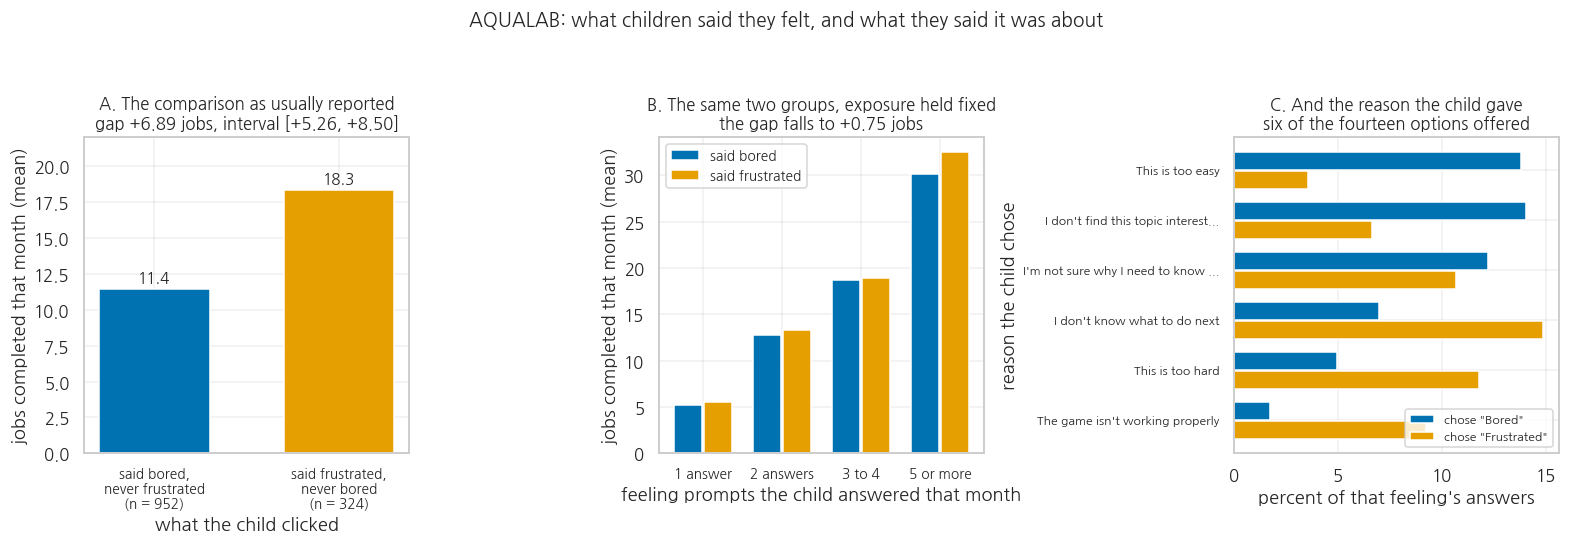

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14.4, 5.0))

ax = axes[0]
raw_b = pair.loc[~pair['frustrated'], COMPLETED].mean()
raw_f = pair.loc[pair['frustrated'], COMPLETED].mean()
ax.bar([0, 1], [raw_b, raw_f], 0.6, color=[BLUE, ORANGE])
for i, v in enumerate([raw_b, raw_f]):
    ax.text(i, v + 0.5, '%.1f' % v, ha='center', fontsize=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(['said bored,\nnever frustrated\n(n = %d)' % (~pair['frustrated']).sum(),
                    'said frustrated,\nnever bored\n(n = %d)' % pair['frustrated'].sum()],
                   fontsize=9)
ax.set_xlabel('what the child clicked')
ax.set_ylabel('jobs completed that month (mean)')
ax.set_ylim(0, 22)
ax.set_title('A. The comparison as usually reported\ngap %+.2f jobs, interval [%+.2f, %+.2f]'
             % (gap_fb, lo_fb, hi_fb))

ax = axes[1]
xb = np.arange(len(band))
ax.bar(xb - 0.19, band['mean jobs, bored'], 0.36, color=BLUE, label='said bored')
ax.bar(xb + 0.19, band['mean jobs, frustrated'], 0.36, color=ORANGE, label='said frustrated')
ax.set_xticks(xb)
ax.set_xticklabels([str(i) for i in band.index], fontsize=9)
ax.set_xlabel('feeling prompts the child answered that month')
ax.set_ylabel('jobs completed that month (mean)')
ax.set_title('B. The same two groups, exposure held fixed\nthe gap falls to %+.2f jobs'
             % adjusted)
ax.legend(fontsize=9, loc='upper left')

ax = axes[2]
show = ['This is too easy', "I don't find this topic interesting",
        "I'm not sure why I need to know this", "I don't know what to do next",
        'This is too hard', "The game isn't working properly"]
bored_pct = [100 * (said[said['feeling'] == 'Bored']['reason'] == r).sum()
             / (said['feeling'] == 'Bored').sum() for r in show]
frus_pct = [100 * (said[said['feeling'] == 'Frustrated']['reason'] == r).sum()
            / (said['feeling'] == 'Frustrated').sum() for r in show]
yy = np.arange(len(show))[::-1]
ax.barh(yy + 0.19, bored_pct, 0.36, color=BLUE, label='chose "Bored"')
ax.barh(yy - 0.19, frus_pct, 0.36, color=ORANGE, label='chose "Frustrated"')
ax.set_yticks(yy)
ax.set_yticklabels([r if len(r) < 34 else r[:32] + '...' for r in show], fontsize=8)
ax.set_xlabel("percent of that feeling's answers")
ax.set_ylabel('reason the child chose')
ax.set_title('C. And the reason the child gave\nsix of the fourteen options offered')
ax.legend(fontsize=8, loc='lower right')

fig.suptitle('AQUALAB: what children said they felt, and what they said it was about',
             fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

**Let's look at the output.** Panel C required no statistics at all.

When a child chose **Bored**, the reason most often given, after "I'm just feeling that way", was
**"I don't find this topic interesting"** (14.1 percent), then **"This is too easy"** (13.8
percent), then **"I'm not sure why I need to know this"** (12.3 percent). Those three together are
40.2 percent of the boredom answers, and all three point at the content in front of the child
rather than at the child.

When a child chose **Frustrated**, the reasons were **"I don't know what to do next"** (14.9
percent), **"This is too hard"** (11.8 percent), and **"The game isn't working properly"** (9.2
percent). That last one is a bug report.

So the sentence "bored children complete less of the game" is available in this data, and there are
two reasons to be careful with it. Statistically, most of the gap is exposure. And on the question
of what boredom is about, the children were asked directly, and their answers name the topic and
the difficulty setting rather than themselves.

| | |
|---|---|
| **What the data directly show** | Of 1,551 boredom answers, 14.1 percent chose "I don't find this topic interesting", 13.8 percent "This is too easy", 12.3 percent "I'm not sure why I need to know this"; of 618 frustration answers, 9.2 percent chose "The game isn't working properly" |
| **A plausible interpretation** | What these children called boredom is at least partly a report about the game's content and pitch, which would make it a design finding as much as a player one |
| **What this file cannot establish** | Whether the fourteen options describe what any child actually felt. A menu constrains the answer, "I'm just feeling that way" is the most chosen option in both cases, and the item was answered once by the median respondent |

**Let's discuss.**

1. **The instrument.** The feeling item offers six words. What state might a twelve year old be in
   that none of the six covers, and what happens to that child in every figure above?
2. **The instrument again.** 75.1 percent of player-months never answered. What mechanisms would
   make non-response systematic rather than random, and which direction would each push the
   numbers in panel A?
3. **The setting.** 9.2 percent of "Frustrated" answers were "The game isn't working properly."
   What should a design team do with that number, and what should a *research* team do with those
   rows? Are those the same rows you would want in a study of affect?
4. **The write-up.** How would you rewrite the headline *"Bored students complete fewer tasks."* so
   that it is both accurate and useful? It may be worth aiming for a version that makes no claim
   about a kind of student.
5. Panel B moved 89 percent of an effect by holding one nuisance variable fixed. Is there a paper
   you have read this semester that compared two groups of learners without any exposure
   adjustment? What would you now want to ask its authors?

### Your turn 3

Frustration against boredom was our pair. The machinery works on any two of the six words.

`FEELING_A` and `FEELING_B` are set to `'Frustrated'` and `'Bored'`, which reproduces the section. Try `'Confused'` against `'Bored'`, or `'Focused'` against `'Happy'`, or `'Nervous'` against `'Confused'`. Watch the raw gap, then watch the same gap inside each band.

In [19]:
# TODO: change either or both, and rerun.
FEELING_A = 'Frustrated'     # working defaults: the notebook runs as is
FEELING_B = 'Bored'

a_only = answered['said_' + FEELING_A] & ~answered['said_' + FEELING_B]
b_only = answered['said_' + FEELING_B] & ~answered['said_' + FEELING_A]
comp = answered[a_only | b_only].copy()
comp['is_a'] = a_only[a_only | b_only].to_numpy()
comp['answers_band'] = pd.cut(comp['n_prompts_answered'], [0, 1, 2, 4, 1000],
                              labels=['1 answer', '2 answers', '3 to 4', '5 or more'])

if comp['is_a'].sum() < 30 or (~comp['is_a']).sum() < 30:
    print("One of those groups has fewer than 30 player-months. Pick a commoner pair.")
else:
    ga, la, ha = cluster_bootstrap_gap(comp, COMPLETED, 'is_a', 'PlayerID')
    print("%s only (n = %d) versus %s only (n = %d)"
          % (FEELING_A, comp['is_a'].sum(), FEELING_B, (~comp['is_a']).sum()))
    print("   raw gap in jobs completed  %+.2f  [%+.2f, %+.2f]" % (ga, la, ha))
    print()
    within = comp.groupby(['answers_band', 'is_a'], observed=True)[COMPLETED].agg(
        ['size', 'mean']).unstack()
    print(within.round(2).to_string())

Frustrated only (n = 324) versus Bored only (n = 952)
   raw gap in jobs completed  +6.89  [+5.26, +8.50]

              size         mean       
is_a         False True   False  True 
answers_band                          
1 answer       571   106   5.17   5.52
2 answers      135    53  12.79  13.32
3 to 4         107    53  18.74  18.98
5 or more      139   112  30.16  32.48


**Let's discuss.** Whichever pair you chose, what happened to the raw gap inside the bands? One
general rule may be forming here about comparisons between two groups defined by *something a
person did during an activity*. How would you write that rule, and notice whether it has anything
to do with emotions.

## 6. The second game, and the disagreement

Everything so far came from one game. That is how most published findings in this field arrive, and
it is one reason so many of them do not travel.

**WAVES** is a different game by the same lab: a signal-matching puzzle across 35 numbered levels.
One row is one session, not one month. It has its own difficulty spike, and we can ask it the same
question.

*Connecting to the readings.* Kim, Knowles, Scianna, Lin and Ruiperez-Valiente (2023) treat
validity and generalizability as empirical questions that log data can be made to address: does the
game measure what it claims to, and does the measurement hold beyond the sample it was built on?
This section is a small version of the second question, and the answer it returns is not the
comfortable one.

**Run the cell below.** It describes how the game is structured, and the structure is what causes
the problem after it.

In [20]:
LEVELS = range(35)
began = pd.DataFrame({i: (waves['lvl%d_BeginCount' % i] > 0).astype(int) for i in LEVELS})
finished = pd.DataFrame({i: (waves['lvl%d_Completed' % i] > 0).astype(int) for i in LEVELS})
fails = pd.DataFrame({i: waves['lvl%d_TotalFails' % i] for i in LEVELS})

print("WAVES sessions: %s rows, %s distinct SessionID, %s distinct PersistentSessionID"
      % (format(len(waves), ','), format(waves['SessionID'].nunique(), ','),
         format(waves['PersistentSessionID'].nunique(), ',')))
print()
print("Levels that every single session begins:")
print("  ", [i for i in LEVELS if began[i].sum() == len(waves)])
print()
print("Levels the game lets a session walk past without playing:")
for i in range(1, 34):
    if began[i].sum() < len(waves) and began[i].sum() < began[i - 1].sum() \
            and began[i + 1].sum() > began[i].sum():
        print("   level %-2d begun by %4d sessions (%.1f%%), yet level %d is begun by %d"
              % (i, began[i].sum(), 100 * began[i].mean(), i + 1, began[i + 1].sum()))

SPIKE_LEVEL = 9
met = began[SPIKE_LEVEL] == 1

print()
print("MEAN FAILS PER LEVEL, WITH TWO DIFFERENT DENOMINATORS")
print("   level   sessions that began it   mean over those   mean over all %s"
      % format(len(waves), ','))
for i in range(1, 11):
    rows = began[i] == 1
    print("   %-6d %-24d %-17.2f %.2f"
          % (i, rows.sum(), fails.loc[rows, i].mean(), fails[i].mean()))
print()
print("Level %d, among the %s sessions that began it: mean %.2f fails, median %.1f, most %d."
      % (SPIKE_LEVEL, format(int(met.sum()), ','), fails.loc[met, SPIKE_LEVEL].mean(),
         fails.loc[met, SPIKE_LEVEL].median(), fails[SPIKE_LEVEL].max()))
earlier = fails[[i for i in range(1, 9)]].mean()
print("Levels 1 to 8, which every session begins, average between %.2f and %.2f fails."
      % (earlier.min(), earlier.max()))
print("So level %d is about %.1f times the worst of them."
      % (SPIKE_LEVEL, fails.loc[met, SPIKE_LEVEL].mean() / earlier.max()))
print()
print("Of the %s sessions that began level %d, %.1f%% went on to begin level %d."
      % (format(int(met.sum()), ','), SPIKE_LEVEL,
         100 * began.loc[met, SPIKE_LEVEL + 1].mean(), SPIKE_LEVEL + 1))

WAVES sessions: 1,581 rows, 1,581 distinct SessionID, 1,565 distinct PersistentSessionID

Levels that every single session begins:
   [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16]

Levels the game lets a session walk past without playing:
   level 9  begun by 1041 sessions (65.8%), yet level 10 is begun by 1581
   level 17 begun by  634 sessions (40.1%), yet level 18 is begun by 1402
   level 29 begun by  191 sessions (12.1%), yet level 30 is begun by 396
   level 32 begun by  162 sessions (10.2%), yet level 33 is begun by 334

MEAN FAILS PER LEVEL, WITH TWO DIFFERENT DENOMINATORS
   level   sessions that began it   mean over those   mean over all 1,581
   1      1581                     2.20              2.20
   2      1581                     3.75              3.75
   3      1581                     3.29              3.29
   4      1581                     5.65              5.65
   5      1581                     1.77              1.77
   6      1581                     2.7

**Let's look at the output.** It shows a real difficulty spike, and it shows a denominator
problem that is the reason this section exists.

**The spike is real and it is sharper than AQUALAB's.** Level 9 costs a mean of **17.29** fails
against **1.31 to 5.65** for levels 1 to 8, which every session begins, roughly **3.1 times** the
hardest of them. The median is 7 and the longest tail is 286.

**The denominator changes the answer.** Levels 1 to 8 are begun by all 1,581 sessions. Level 9 is
begun by 1,041 of them, because WAVES lets a session skip past it. Average level 9's fails over all
1,581 rows and you get **11.38**, because 540 sessions contribute a zero they never had the chance
to earn. Average over the sessions that actually met the level and you get **17.29**.

Both numbers are arithmetically correct. They answer different questions: *how much did this level
cost the average session in this file* against *how much did this level cost a child who met it*.
Publishing either without naming the denominator is how a difficulty analysis goes wrong.

**One structural difference decides the rest of the section.** Of the sessions that began level 9,
**100.0 percent** went on to begin level 10. In WAVES the game moves you on. In AQUALAB the child
decides whether there is a next job, and 66.0 percent of the time at `coral-hunting-lions` there
was not.

That does **not** mean nobody stops in WAVES. Depth still varies enormously: among the sessions
that met level 9, the deepest level reached runs from 16 to 34 and only 13 percent get to the last
one. What the 100 percent buys us is narrow, and worth stating precisely. The confound that undid
the AQUALAB comparison was that the record *ended at the hard job itself*, which is why 66.0
percent against 21.9 percent mattered so much. In WAVES that particular thing cannot happen, so
persistence at the spike and continuing past the spike are not the same variable. Stopping later is
still possible, and the next cell reports the deepest level reached alongside the headline so that
you can see how much of it there is.

**Run the cell below.**

In [21]:
waves['fails_at_spike'] = fails[SPIKE_LEVEL]
waves['levels_after_spike'] = finished[[i for i in range(SPIKE_LEVEL + 1, 35)]].sum(axis=1)
waves['deepest_level'] = began.apply(lambda r: max(i for i in LEVELS if r[i] == 1), axis=1)

reached = waves[met].copy()
reached['persisted'] = reached['fails_at_spike'] > 10

w_summary = reached.groupby('persisted').agg(
    sessions=('fails_at_spike', 'size'),
    mean_fails=('fails_at_spike', 'mean'),
    levels_after=('levels_after_spike', 'mean'),
    deepest=('deepest_level', 'mean'),
)
w_summary.index = ['10 fails or fewer', 'more than 10 fails']
print(w_summary.round(2).to_string())


def simple_bootstrap_gap(frame, value_col, flag_col, n_boot=2000, seed=SEED):
    """One row is one session here. There are 1,565 distinct PersistentSessionIDs
    across 1,581 sessions, so at most sixteen rows share a persistent id with
    another row: the nesting that mattered so much in AQUALAB is negligible
    here, and resampling rows is honest in this table where it was not in
    that one."""
    rng = np.random.default_rng(seed)
    y = frame[value_col].to_numpy(dtype=float)
    g = frame[flag_col].to_numpy(dtype=bool)
    draws = np.empty(n_boot)
    for b in range(n_boot):
        take = rng.integers(0, len(y), len(y))
        yy, gg = y[take], g[take]
        draws[b] = yy[gg].mean() - yy[~gg].mean()
    return y[g].mean() - y[~g].mean(), np.percentile(draws, 2.5), np.percentile(draws, 97.5)


print()
for label, col in [('levels completed after the spike', 'levels_after_spike'),
                   ('deepest level reached           ', 'deepest_level')]:
    o, lo_, hi_ = simple_bootstrap_gap(reached, col, 'persisted')
    print("%s  gap %+.2f  [%+.2f, %+.2f]" % (label, o, lo_, hi_))

print()
print("Rank correlation, fails at level %d and levels completed after it: rho = %+.3f"
      % (SPIKE_LEVEL, spearman(reached['fails_at_spike'], reached['levels_after_spike'])))
reached['fails_quartile'] = pd.qcut(reached['fails_at_spike'], 4)
wq = reached.groupby('fails_quartile', observed=True)['levels_after_spike'].agg(
    ['size', 'mean'])
print(wq.round(2).to_string())

                    sessions  mean_fails  levels_after  deepest
10 fails or fewer        597        3.29         14.28    24.74
more than 10 fails       444       36.11         15.13    25.35

levels completed after the spike  gap +0.85  [+0.13, +1.60]
deepest level reached             gap +0.61  [-0.11, +1.39]

Rank correlation, fails at level 9 and levels completed after it: rho = +0.055
                size   mean
fails_quartile             
(-0.001, 2.0]    293  14.09
(2.0, 7.0]       239  14.67
(7.0, 21.0]      255  14.92
(21.0, 286.0]    254  15.00


**Let's look at the output.** In WAVES, sessions that failed level 9 more than ten times
completed **15.13** later levels against **14.28**. A gap of **+0.85** [+0.13, +1.60], out of 25
levels available. The rank correlation is **+0.055**. The four quartiles of failure average 14.09,
14.67, 14.92 and 15.00 levels afterwards.

The direction is the same as AQUALAB's, and the size is negligible.

Two findings measured in different units are hard to compare, so the next cell puts both on one
scale. `prob_higher` gives the probability that a randomly chosen record above the threshold
finishes more than a randomly chosen record below it. It is a rank statistic, so it works on jobs
and levels alike, and 0.50 means the groups are completely interleaved.

**Run the cell below.**

In [22]:
def prob_higher_interval(frame, value_col, flag_col, cluster_col=None,
                         n_boot=2000, seed=SEED):
    """Same statistic, with an interval. Pass cluster_col where rows nest inside
    people (AQUALAB) and leave it out where they do not (WAVES)."""
    rng = np.random.default_rng(seed)
    y = frame[value_col].to_numpy(dtype=float)
    g = frame[flag_col].to_numpy(dtype=bool)
    observed = prob_higher(y[g], y[~g])
    if cluster_col is None:
        units = [np.array([i]) for i in range(len(frame))]
    else:
        codes, names = pd.factorize(frame[cluster_col])
        units = [np.flatnonzero(codes == i) for i in range(len(names))]
    draws = []
    for _ in range(n_boot):
        pick = rng.integers(0, len(units), len(units))
        rows = np.concatenate([units[i] for i in pick])
        yy, gg = y[rows], g[rows]
        if gg.any() and (~gg).any():
            draws.append(prob_higher(yy[gg], yy[~gg]))
    draws = np.array(draws)
    return observed, np.percentile(draws, 2.5), np.percentile(draws, 97.5)


aq = prob_higher_interval(spike, 'JobsCompleted-UniqueCount', 'persisted', 'PlayerID')
aq_still = prob_higher_interval(still, 'completed_after', 'persisted', 'PlayerID')
wv = prob_higher_interval(reached, 'levels_after_spike', 'persisted')

print("PROBABILITY THAT A RECORD ABOVE THE THRESHOLD FINISHES MORE THAN ONE BELOW IT")
print("Above the threshold means more than 10 argumentation tries at this AQUALAB job,")
print("or more than 10 fails at WAVES level %d. Both thresholds are ours." % SPIKE_LEVEL)
print("0.50 would mean the two groups are completely interleaved.")
print()
print("AQUALAB, everyone who attempted the job        %.3f  [%.3f, %.3f]   n = %d"
      % (aq[0], aq[1], aq[2], len(spike)))
print("AQUALAB, only those completing any more jobs  %.3f  [%.3f, %.3f]   n = %d"
      % (aq_still[0], aq_still[1], aq_still[2], len(still)))
print("WAVES,   everyone who met level %d              %.3f  [%.3f, %.3f]   n = %s"
      % (SPIKE_LEVEL, wv[0], wv[1], wv[2], format(len(reached), ',')))

PROBABILITY THAT A RECORD ABOVE THE THRESHOLD FINISHES MORE THAN ONE BELOW IT
Above the threshold means more than 10 argumentation tries at this AQUALAB job,
or more than 10 fails at WAVES level 9. Both thresholds are ours.
0.50 would mean the two groups are completely interleaved.

AQUALAB, everyone who attempted the job        0.749  [0.709, 0.787]   n = 617
AQUALAB, only those completing any more jobs  0.454  [0.307, 0.606]   n = 210
WAVES,   everyone who met level 9              0.531  [0.496, 0.567]   n = 1,041


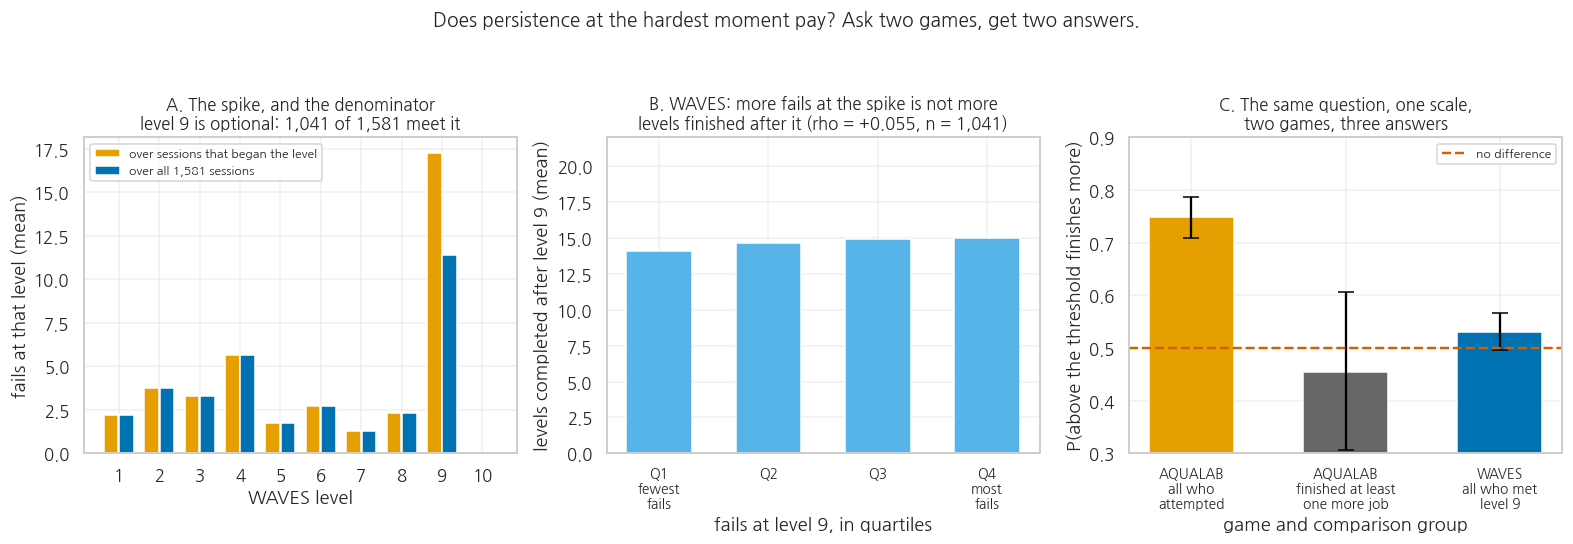

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14.4, 5.0))

ax = axes[0]
lv = list(range(1, 11))
mean_over_players = [fails.loc[began[i] == 1, i].mean() for i in lv]
mean_over_all = [fails[i].mean() for i in lv]
xx = np.arange(len(lv))
ax.bar(xx - 0.19, mean_over_players, 0.36, color=ORANGE,
       label='over sessions that began the level')
ax.bar(xx + 0.19, mean_over_all, 0.36, color=BLUE, label='over all 1,581 sessions')
ax.set_xticks(xx)
ax.set_xticklabels(lv)
ax.set_xlabel('WAVES level')
ax.set_ylabel('fails at that level (mean)')
ax.set_title('A. The spike, and the denominator\nlevel 9 is optional: 1,041 of 1,581 meet it')
ax.legend(fontsize=8)

ax = axes[1]
wm = wq['mean'].to_numpy()
ax.bar(np.arange(len(wm)), wm, 0.6, color=SKY)
ax.set_xticks(np.arange(len(wm)))
ax.set_xticklabels(['Q1\nfewest\nfails', 'Q2', 'Q3', 'Q4\nmost\nfails'], fontsize=9)
ax.set_xlabel('fails at level 9, in quartiles')
ax.set_ylabel('levels completed after level 9 (mean)')
ax.set_ylim(0, 22)
ax.set_title('B. WAVES: more fails at the spike is not more\nlevels finished after it (rho = %+.3f, n = %s)'
             % (spearman(reached['fails_at_spike'], reached['levels_after_spike']),
                format(len(reached), ',')))

ax = axes[2]
names_ = ['AQUALAB\nall who\nattempted', 'AQUALAB\nfinished at least\none more job',
          'WAVES\nall who met\nlevel 9']
vals = [aq[0], aq_still[0], wv[0]]
errs = np.array([[v - c[1] for v, c in zip(vals, [aq, aq_still, wv])],
                 [c[2] - v for v, c in zip(vals, [aq, aq_still, wv])]])
ax.bar(np.arange(3), vals, 0.55, color=[ORANGE, GREY, BLUE],
       yerr=errs, capsize=5, ecolor='black')
ax.axhline(0.5, color=RED, lw=1.6, ls='--', label='no difference')
ax.set_xticks(np.arange(3))
ax.set_xticklabels(names_, fontsize=9)
ax.set_xlabel('game and comparison group')
ax.set_ylabel('P(above the threshold finishes more)')
ax.set_ylim(0.3, 0.9)
ax.set_title('C. The same question, one scale,\ntwo games, three answers')
ax.legend(fontsize=8, loc='upper right')

fig.suptitle('Does persistence at the hardest moment pay? Ask two games, get two answers.',
             fontsize=12.5)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

**Let's look at the output.** The three answers on one scale:

| Comparison | P(above the threshold finishes more) | 95 percent interval | n |
|---|---|---|---|
| AQUALAB, everyone who attempted the job | **0.749** | 0.709 to 0.787 | 617 |
| AQUALAB, only those who completed at least one more job | **0.454** | 0.307 to 0.606 | 210 |
| WAVES, everyone who met level 9 | **0.531** | 0.496 to 0.567 | 1,041 |

It may be worth holding off on resolving this.

The first row is what a paper would report. The second row says most of the first row was carried
by whether any further job got finished at all, which in this file is very nearly the outcome
itself and is not the same as knowing who was still playing. The third row asks the same question
in a game where the next level arrives whether or not the player asks for it, and finds almost
nothing.

One story reconciles them: in AQUALAB the child chooses whether there is a next job, so persistence
and progress are the same decision seen twice; in WAVES the game supplies the next level
regardless, so persistence at one level tells you very little about the twenty-five that follow.
That story has a cost too. WAVES sessions do end, at depths running from 16 to 34, and the
persisting group reaches 0.61 levels deeper on average with an interval of [-0.11, +1.39] that
touches zero, which is the same pattern as AQUALAB's arriving small instead of large. The story is
consistent with everything above. It is also unfalsifiable with these two files, and other stories
fit: WAVES sessions are minutes long and AQUALAB months are months long; a puzzle level and a
scientific argument may reward persistence differently; the WAVES children and the AQUALAB children
are different children.

A finding that appears in one game and not in another still gives you a claim, bounded to the game
it appeared in. Reporting the bound alongside the finding is what keeps the claim usable.

**Let's discuss.**

1. Which of the three rows would you put in an abstract? What would a reader of that abstract be
   entitled to believe, and what would they not?
2. The WAVES interval is [0.496, 0.567], which contains 0.50 by a small margin on one side. What
   sentence describing that result would a careful reader accept? What sentence might a press
   office write instead, and which word does the damage?
3. What third study would separate the two explanations offered above, "the games differ in whether
   the player chooses to continue" against "the games differ in what persistence is good for"?
   What would you need to log, and could you get it from an existing public dataset?
4. Suppose the WAVES result had come out at 0.74 as well. Would you believe the AQUALAB finding
   more? Should you? This is a question about what replication does and does not buy you when both
   studies share a design feature.

### 6.1 The pre, post and gain columns

The WAVES extract ships columns called `pre`, `post` and `gain`. A name like that suggests a
learning outcome, and this course has spent a semester wanting one. It is worth taking apart before
it is used.

**Run the cell below.**

In [24]:
print("WAVES ships a 'gain' column. Take it apart before you use it.")
print("   pre  = c0 + c1 for %.0f%% of sessions"
      % (100 * (waves['pre'] == waves['c0'] + waves['c1']).mean()))
print("   post = c2 + c3 for %.0f%% of sessions"
      % (100 * (waves['post'] == waves['c2'] + waves['c3']).mean()))
print("   gain = post - pre for %.0f%% of sessions"
      % (100 * (waves['gain'] == waves['post'] - waves['pre']).mean()))
print()
print("   mean pre  %.2f out of 2" % waves['pre'].mean())
print("   mean post %.2f out of 2" % waves['post'].mean())
print("   mean gain %.2f" % waves['gain'].mean())
print()
print("   sessions with gain below zero: %.1f%%" % (100 * (waves['gain'] < 0).mean()))
print("   sessions with gain exactly zero: %.1f%%" % (100 * (waves['gain'] == 0).mean()))
print("   sessions with gain above zero: %.1f%%" % (100 * (waves['gain'] > 0).mean()))

WAVES ships a 'gain' column. Take it apart before you use it.
   pre  = c0 + c1 for 100% of sessions
   post = c2 + c3 for 100% of sessions
   gain = post - pre for 100% of sessions

   mean pre  1.47 out of 2
   mean post 1.05 out of 2
   mean gain -0.42

   sessions with gain below zero: 45.9%
   sessions with gain exactly zero: 39.8%
   sessions with gain above zero: 14.3%


**Let's look at the output.** `pre` is two questions (`c0`, `c1`). `post` is two **different**
questions (`c2`, `c3`). `gain` is one subtracted from the other, and its mean is **-0.42**. Nearly
half of all sessions, 45.9 percent, "lost" ground.

The obvious sentence is *"playing WAVES made children worse at waves."* It is available and it is
arithmetically correct. It is also more than these columns can support: a two-item score against a
**different** two-item score is mostly a difference between four questions rather than a difference
in knowledge. A score with two items has very little room to be reliable in the first place, and a
difference between two such scores is noisier than either of them, so a per-session `gain` here
would be close to noise even if the four items had been identical.

**Let's discuss.** You have now met three ways for a real dataset to hand you a wrong answer that
looks right: a column of zeros with a promising name (`argtime`), a denominator that changes with
the question (WAVES level 9), and an outcome variable that is not one (`gain`). What do all three
have in common, and is there a single habit that catches all three? It may be worth writing it as
an instruction to yourself for your own dissertation data.

### Your turn 4

Level 9 is not the only optional level in WAVES. There are four, and each is a difficulty spike with its own denominator problem.

`YOUR_LEVEL` is set to 9, which reproduces the section. Try 17, 29, or 32.

In [25]:
# TODO: change the level and rerun. 9, 17, 29 and 32 are the optional ones.
YOUR_LEVEL = 9              # working default: the notebook runs as is

if began[YOUR_LEVEL].sum() < 60:
    print("Only %d sessions began level %d. Try 9, 17, 29, or 32."
          % (began[YOUR_LEVEL].sum(), YOUR_LEVEL))
else:
    hit = began[YOUR_LEVEL] == 1
    sub = waves[hit].copy()
    sub['fails_here'] = fails.loc[hit, YOUR_LEVEL]
    sub['levels_after'] = finished.loc[hit, [i for i in range(YOUR_LEVEL + 1, 35)]].sum(axis=1)
    sub['persisted'] = sub['fails_here'] > 10
    print("WAVES level %d" % YOUR_LEVEL)
    print("   begun by %d of %d sessions (%.1f%%)"
          % (hit.sum(), len(waves), 100 * hit.mean()))
    print("   mean fails among those sessions %.2f, median %.1f"
          % (sub['fails_here'].mean(), sub['fails_here'].median()))
    print("   mean fails over all sessions    %.2f" % fails[YOUR_LEVEL].mean())
    if sub['persisted'].sum() >= 20 and (~sub['persisted']).sum() >= 20:
        gw, lw, hw = simple_bootstrap_gap(sub, 'levels_after', 'persisted')
        print("   gap in levels completed afterwards %+.2f  [%+.2f, %+.2f]" % (gw, lw, hw))
        print("   rank correlation, fails and levels after: rho = %+.3f"
              % spearman(sub['fails_here'], sub['levels_after']))
    else:
        print("   at this level one persistence group is under 20 sessions,")
        print("   so the comparison is not worth running. See Solution 4 for the fix.")

WAVES level 9
   begun by 1041 of 1581 sessions (65.8%)
   mean fails among those sessions 17.29, median 7.0
   mean fails over all sessions    11.38


   gap in levels completed afterwards +0.85  [+0.13, +1.60]
   rank correlation, fails and levels after: rho = +0.055


**Let's discuss.** For the level you chose, how far apart are the two denominators, and by what
factor? Levels 29 and 32 are met by roughly a tenth of sessions. What kind of session gets that
far, and what does that do to any claim about "how hard level 32 is"? This is range restriction,
and it is the same problem you met in AQUALAB in a different form.

## 7. These are children

Everything above treated this as a methods problem. It is also a file about children, and the file
will say so if you ask it.

**Run the cell below.**

In [26]:
AGE_ITEM = 'dem2_DemographicItemResponses'
WHERE_ITEM = 'dem0_DemographicItemResponses'

age = play[AGE_ITEM].dropna()
print("The game asked some players how old they are.")
print("player-months answering the age item: %s of %s (%.1f%%)"
      % (format(len(age), ','), format(len(play), ','), 100 * len(age) / len(play)))
print()
print(play[AGE_ITEM].value_counts().to_string())
under16 = age.isin(['9 or younger', '10-11', '12-13', '13-15']).sum()
print()
print("Of those who answered, %.1f%% said they were 15 or younger."
      % (100 * under16 / len(age)))
print()

where = play[WHERE_ITEM].dropna()
print(play[WHERE_ITEM].value_counts().to_string())
print()
print("Of those who answered, %.1f%% said they were playing at school."
      % (100 * where.isin(['School', 'En el colegio']).sum() / len(where)))

The game asked some players how old they are.
player-months answering the age item: 6,092 of 18,959 (32.1%)

dem2_DemographicItemResponses
12-13                      2520
13-15                      1601
10-11                       979
16 or older                 811
9 or younger                170
16 a\u00f1os o m\u00e1s      11

Of those who answered, 86.5% said they were 15 or younger.

dem0_DemographicItemResponses
School           4819
Home             1247
En el colegio      21
En la casa          5

Of those who answered, 79.4% said they were playing at school.


**Let's look at the output.** **86.5 percent** of those who answered the age item said they were
15 or younger. The largest single group said **12 to 13**. **79.4 percent** said they were playing
**at school**.

Those three numbers are worth reading with their denominator attached. The age item was answered in
**6,092 of 18,959 player-months**, which is 32.1 percent, and the same 6,092 answered the location
item. Both are self-reports on an optional in-game question, offered in bands rather than exact
ages, and one of the response strings arrived in Spanish. So these are not the demographics of
AQUALAB's players; they are the demographics of the third who answered, and nothing in the file
would tell you how the other two thirds differ.

| | |
|---|---|
| **What the data directly show** | Of 6,092 player-months answering the age item, 86.5 percent selected a band at 15 or younger and 2,520 selected 12 to 13; of the same 6,092 answering the location item, 79.4 percent selected School |
| **A plausible interpretation** | The extract is mostly middle school play, and a large part of it happened during lessons rather than at home |
| **What this file cannot establish** | The age or setting of the two thirds who did not answer, whether a band was chosen accurately, or whether answering at all is related to how much a child played |

With that caution attached, the picture is of players who are mostly middle schoolers, often in a
classroom, during a lesson, on a device somebody else chose, playing a game somebody else assigned.
That is enough to change what every design decision in this course means.

**What is different when the user is eleven.**

- **They did not consent and they could not.** A district, a school, or a teacher decided. The
  people who agreed were not the people being logged. Field Day Lab's own answer to this is why the
  data are pseudonymous codenames rather than names, and why the released features are aggregates
  rather than raw event streams.
- **They could not opt out of the setting either.** Among those who answered, 79.4 percent were at
  school. "Voluntary use" is not an accurate phrase for a class period.
- **The affect item is the most intimate thing in this course.** In section 5 you read what children
  said they were feeling and why, in 4,723 player-months of answers. They answered a game, not a
  researcher, and almost certainly not with the understanding that a doctoral seminar would tabulate
  it months later. That the licence permits this is a reason to stop over it rather than a reason
  not to.
- **A label attaches to a person.** Had the section 5 headline shipped as a dashboard, some eleven
  year old would be flagged in front of a teacher on the basis of one click on one Tuesday. Section
  5 suggests such a flag would have been measuring how long they played more than anything else.
- **And a standing commitment of this course applies here.** A child who stops playing is not
  deficient, and a child who says they are bored may be telling you something about your game: 14.1
  percent said the topic did not interest them, 13.8 percent said it was too easy, 12.3 percent said
  they could not see why they needed it. Those are design findings. Writing them up as properties of
  children would go well beyond what the data support.

**A note on why this data exists.** Field Day Lab could have kept these logs. Publishing them under
CC0 means the next researcher with a question about game-based learning does not have to recruit a
new classroom of children to answer it. Every time an open dataset is used well, the case for the
next one gets easier to make.

## Reflection

These prompts are for your own thinking. Nothing here is collected, and there is no length target.
Written answers to two or three of them, including the last, will make Week 11 easier, and one plot
or one question from this notebook is worth bringing to that session.

**On Reardon, Kumar, and Revelle (2022), "Game learning analytics."**
They argue that games give learning analytics something a course platform cannot: dense, repeated,
tightly specified attempts at a known skill, with an outcome the designer chose in advance. This
notebook had all of that, in two games, and the analysis could have gone wrong at four separate
points: a column of zeros with a promising name, a mean four times its median, a persistence effect
that was mostly a record ending, and a `gain` column made of four different questions. Which of the
four do you find most instructive, and what does it imply for the claim that finer-grained data
produces better inferences?

**On D'Mello and Jensen (2022), "Emotional learning analytics."**
Their central move is treating affect as a dynamic state rather than a trait. Section 5 found that
holding the number of prompts fixed removed 89 percent of a large difference between children who
said "frustrated" and children who said "bored". Does that support their argument or complicate it?
Then the harder version: what would a dynamic analysis of this affect item look like, given that
the median respondent answered exactly once?

**On Kim, Knowles, Scianna, Lin, and Ruiperez-Valiente (2023), "Learning analytics application to
examine validity and generalizability of game-based assessment for spatial reasoning."**
They ask whether what a game measures is what it claims to measure, and whether it holds up beyond
the sample it was built on. You ran a small version of that here: a persistence finding at 0.749 in
AQUALAB and 0.531 in WAVES. What paragraph would you put in a discussion section reporting both,
without pretending the disagreement resolves?

**Across the readings, on what an open licence does and does not settle.**
These files are CC0, so you may do anything with them. The children in them are, among those who
answered, mostly twelve and thirteen and mostly at school, and were asked how they were feeling
while a lesson ran. What paragraph would you put in an IRB application or a data-availability
statement that is honest about both of those at once?

**The one worth answering: your own design, rewritten for an eleven year old.**
It may be useful to take one design proposal you have already made this semester, your dashboard,
your model redesign, your collaboration analytics, or the seed of your course research project, and
rewrite its **user** as an eleven year old and its **audience** as that child's teacher, school,
and family.

- What in your proposal stops being defensible?
- Who consents, and what were they told?
- Would you collect an in-game affect item from a child? Retained how long, visible to whom, and
  deleted when?
- Your proposal presumably had an intervention. What does that intervention teach a child about
  themselves? A flag that says "struggling" is also a message, and section 4 showed how easily such
  a flag can be measuring something else.
- The hard one: is there a version of your proposal where the child is a **user** rather than a
  **subject**? Week 11 is about co-design, and this question leads into it.

### A question for our guest

Chaewon Kim, Southern Illinois University, joins us for the last hour this week, and we develop
questions for the Q&A together in the preparation block just before the break. If you work through
this notebook before we meet, something you have just done here is a good source for one. Two
examples:

> "In section 4 we found that persistence at the hardest job predicted far more completion, and
> that almost all of it was whether the child's record continued at all. When you evaluate
> persistence or productive struggle in a game, how do you separate 'this child kept trying' from
> 'this child was still playing'?"

Or, on the affective side:

> "Children in AQUALAB who said they were bored most often gave a reason about the content: not
> interesting, too easy, or they could not see why they needed it. How much of what the field calls
> disengagement do you think is a property of the design rather than the player, and how would you
> get a design team to hear that?"

## Wrapping up

**Nothing from this notebook is collected.** Week 10 is not a mini project; those were weeks 4, 5,
6, and 8. There is no Canvas upload from here, and coding skill is not what this course assesses.
The reading you do of these outputs is the part that carries into Week 11 and into your own
project.

**What is due this week, separately from this notebook:**

- [ ] **Course Research Project Literature Review**, uploaded to Canvas by **11:59 PM on Sunday,
      November 1, 2026**. The Week 10 Literature Review Guidelines handout covers scope, structure
      options, and the difference between synthesis and summary.
- [ ] **Your AI interaction log**, pasted into a Word file and attached to the Canvas AI Reflection
      submission alongside the literature review, **plus the four reflection answers** typed into
      the text box on that same page. The AI Reflection is required whether or not you used AI; if
      you used none, saying so in the text box is a complete answer.

**AI use, per the course policy.** AI assistance is permitted in designated activities and must be
documented. If you used an AI assistant on the literature review, to find sources, to summarize a
paper, to tighten a paragraph, or to question your framing, the full exchange goes in the Word file
and your answers to the syllabus's four reflection questions go in the Canvas text box. Undisclosed
use is an Honor Code violation. Keeping the log as you go tends to be easier than reconstructing it
later.

**A checklist, for your own use:**

- [ ] The notebook ran top to bottom with no errors (**Runtime > Restart session and run all**).
- [ ] You can state, without looking, who collected this data, under what licence, and what one row
      of `players.csv` is.
- [ ] You can name three things that were wrong with the raw files and say what each repair cost.
- [ ] You can say why the mean of 31.98 tries on `coral-hunting-lions` is a worse summary than the
      median of 8, and why the median is not obviously good either.
- [ ] You changed at least one value in a **Your turn** cell and noticed what moved.
- [ ] You can say, in one sentence, the difference between the selection question and the effect
      question in section 4, what the 67.1 percent against 3.1 percent counts, and why that flag is
      a decomposition of the outcome rather than a fact about who was still playing.
- [ ] You can state all three numbers on the common scale, 0.749, 0.454 and 0.531, and say which
      question each one answers.
- [ ] You have thought about at least two Reflection prompts, including the one about eleven year
      olds.
- [ ] You have one question written down for Chaewon Kim.
- [ ] Literature review and AI interaction log are uploaded to Canvas.

Week 11 is the co-design studio. One plot or one question from this notebook is worth bringing to
it.

## Going further (optional)

Everything below is optional. These are worked versions of the four **Your turn** cells rather than
the only right answers, and they are more useful after you have tried your own.

### Solution 1: is the skew special, or is it everywhere?

One job at a time is fine for looking. For an argument, score every job that enough children attempted and look at the whole distribution of skew.

In [27]:
sol1 = jobs.groupby('job').agg(n=('tries', 'size'), mean=('tries', 'mean'),
                               median=('tries', 'median'))
sol1 = sol1[(sol1['n'] >= 300) & (sol1['mean'] > 0)].copy()
sol1['top5_share'] = [100 * jobs.loc[jobs['job'] == j, 'tries'].nlargest(
    max(1, int(round(0.05 * n)))).sum() / jobs.loc[jobs['job'] == j, 'tries'].sum()
    for j, n in zip(sol1.index, sol1['n'])]
sol1 = sol1.sort_values('top5_share', ascending=False)

print("Every job attempted by 300 or more player-months, most concentrated first.")
print("top5_share is the percent of all tries on that job supplied by its busiest 5%.")
print()
print(sol1.round(2).to_string())
print()
have_median = sol1[sol1['median'] > 0]
print("Of the %d jobs with a non-zero median, %d have a mean at least twice the median."
      % (len(have_median), (have_median['mean'] >= 2 * have_median['median']).sum()))
print("Median top-5%% share across all %d jobs: %.1f%%."
      % (len(sol1), sol1['top5_share'].median()))
print("The lowest top-5%% share of any of them: %.1f%%." % sol1['top5_share'].min())

Every job attempted by 300 or more player-months, most concentrated first.
top5_share is the percent of all tries on that job supplied by its busiest 5%.

                                    n   mean  median  top5_share
job                                                             
bayou-alt-energy                  698   3.93     0.0       61.73
arctic-endangered-seals           589   2.46     0.0       60.47
coral-turtle-population          2991   2.44     0.0       56.83
arctic-disappearing-act          1046   1.01     0.0       56.56
coral-ocean-plastics              601   1.83     1.0       55.99
turtle-danger2                    519   1.21     0.0       54.13
arctic-stationary-survival       1222   1.79     1.0       52.72
coral-lionfish-conspiracy        1719   1.87     0.0       48.99
turtle-danger                     826   1.43     0.0       48.27
arctic-salmon-monitoring         2897   3.38     1.0       46.80
coral-turtle-stability            809   2.30     1.0       46.69


**Let's look at the output.** The busiest 5 percent of player-months supply a **median of 37.4
percent** of all the tries on a job, and even the least concentrated job in the game gives them
**20.5 percent**. So `coral-hunting-lions` is not unusual in the *shape* of its distribution; it is
unusual in the *level*.

That is a warning about a whole genre of measurement. Voluntary-play counts are concentrated by
construction, since a small number of people play a great deal. Any per-job or per-level mean in a
game telemetry paper is doing what you just watched, and most such papers report only the mean.

### Solution 2: sweep the threshold, and watch the confound track the finding

If the section 4 story is right, then as the threshold moves, the raw gap should move **with the difference in who completed anything more**, because they are very nearly the same thing.

In [28]:
rows = []
for t in [1, 2, 5, 10, 20, 40, 80]:
    tmp = spike.copy()
    tmp['persisted'] = tmp['tries'] > t
    if tmp['persisted'].sum() < 20 or (~tmp['persisted']).sum() < 20:
        continue
    g0, l0, h0 = cluster_bootstrap_gap(tmp, 'JobsCompleted-UniqueCount',
                                       'persisted', 'PlayerID', n_boot=800)
    rows.append({'threshold': t,
                 'n persisted': int(tmp['persisted'].sum()),
                 'raw gap': g0, 'lo': l0, 'hi': h0,
                 'finished more, persisted %':
                     100 * tmp.loc[tmp['persisted'], 'finished_more_after'].mean(),
                 'finished more, other %':
                     100 * tmp.loc[~tmp['persisted'], 'finished_more_after'].mean()})

sweep = pd.DataFrame(rows).set_index('threshold')
print(sweep.round(2).to_string())
print()
print("Across thresholds, correlation between the raw gap and the difference in")
print("the share completing any more jobs: r = %.3f"
      % np.corrcoef(sweep['raw gap'],
                    sweep['finished more, persisted %']
                    - sweep['finished more, other %'])[0, 1])

           n persisted  raw gap     lo     hi  finished more, persisted %  finished more, other %
threshold                                                                                        
1                  346    14.46  12.02  16.94                       60.69                    0.00
2                  332    14.46  12.02  16.89                       63.25                    0.00
5                  320    14.90  12.45  17.39                       65.62                    0.00
10                 298    14.81  12.30  17.25                       67.11                    3.13
20                 253    14.59  12.11  17.12                       69.17                    9.62
40                 178    12.96  10.27  15.74                       69.66                   19.59
80                  87    10.10   6.30  13.51                       70.11                   28.11

Across thresholds, correlation between the raw gap and the difference in
the share completing any more jobs: r = 0.96

**Let's look at the output.** The raw gap is remarkably stable from a threshold of 1 to a
threshold of 20, between **+14.46** and **+14.90**, and only starts to fall at 40 and 80 as the
"persisted" group shrinks towards the few dozen heaviest players. A naive reading would call that
stability robustness.

Across the seven thresholds, the raw gap correlates with the difference in "share completing any
more jobs" at **r = 0.961**. The finding tracks its own confound almost perfectly, which is what a
confound looks like once it is plotted alongside the result. Stability across a threshold sweep
tells you the *definition* is not fragile. It tells you nothing about whether the thing you defined
is what you think it is.

### Solution 3: do this for all six feelings at once

Section 5 compared two words. If the exposure argument is right, it should not matter which word you pick: every feeling should show a large raw gap and almost none of it should survive.

In [29]:
# A narrow working table, so the loop is not copying 150 columns six times.
small = pd.DataFrame({
    'jobs': answered[COMPLETED].to_numpy(),
    'answers': answered['n_prompts_answered'].to_numpy(),
    'band': pd.cut(answered['n_prompts_answered'], [0, 1, 2, 4, 1000],
                   labels=['1', '2', '3 to 4', '5 or more']).to_numpy(),
})

rows = []
for word in FEELINGS:
    small['flag'] = answered['said_' + word].to_numpy()
    raw = small.loc[small['flag'], 'jobs'].mean() - small.loc[~small['flag'], 'jobs'].mean()
    total, weight = 0.0, 0.0
    for _, part in small.groupby('band', observed=True):
        a, b = part[part['flag']], part[~part['flag']]
        if len(a) and len(b):
            total += len(part) * (a['jobs'].mean() - b['jobs'].mean())
            weight += len(part)
    rows.append({'feeling': word,
                 'player-months': int(small['flag'].sum()),
                 'mean answers given': small.loc[small['flag'], 'answers'].mean(),
                 'raw gap in jobs': raw,
                 'gap holding answers fixed': total / weight})

sol3 = pd.DataFrame(rows).set_index('feeling').sort_values('raw gap in jobs',
                                                           ascending=False)
print("Each feeling against everyone who never said it, before and after")
print("holding the number of prompts answered fixed.")
print()
print(sol3.round(2).to_string())

Each feeling against everyone who never said it, before and after
holding the number of prompts answered fixed.

            player-months  mean answers given  raw gap in jobs  gap holding answers fixed
feeling                                                                                  
Frustrated            436                4.19            10.47                       0.36
Nervous               191                4.29            10.24                       0.34
Focused              2072                2.95             6.61                       1.03
Happy                2097                2.80             4.85                       0.38
Confused              365                2.94             3.93                      -0.09
Bored                1064                2.60             2.03                      -0.39


**Let's look at the output.** Every one of the six words shows a large raw gap: **+10.47** for
Frustrated, **+10.24** for Nervous, **+6.61** for Focused, **+4.85** for Happy, **+3.93** for
Confused, **+2.03** for Bored. Hold the number of answers fixed and all six collapse into the range
**-0.39 to +1.03**.

Please read the ordering of the raw column beside the next one. It is almost exactly the ordering
of "mean answers given", and it has nothing to do with what the words mean. **Saying any word at
all is a marker of having been asked more often, and being asked more often is a marker of playing
more.** A paper that reported the Frustrated row alone would have found the sampling design of the
affect item and described it as an emotion finding.

### Solution 4: all four optional WAVES levels, split at their own median

The `> 10 fails` threshold is borrowed from AQUALAB and it leaves too few sessions on one side at levels 29 and 32. Split each level at **its own** median instead, so the two groups stay comparable in size and the test is the same test everywhere.

**The median split is a rank inside a pool.** `sub['fails_here'] > sub['fails_here'].median()` cuts each level's sessions at their own middle value, so the size of the labelled group is set by the rule and by where the ties fall rather than by the game: 509 of 1,041 at level 9, and 61 of 162 at level 32. The line also moves from level to level, since above the median is more than 7 fails at level 9 and more than 2 fails at level 32, so a session that failed three times sits above the line at level 32 and below it at level 9. Please compare the membership with the fixed rule in section 6, where 444 of these same 1,041 level 9 sessions sat above 10 fails while 509 sit above the median here, so the two rules disagree about 65 sessions whose play nobody has re-examined. Kim and colleagues define persistence the same way, by percentile against classmates, which is why this column is more accurately read as "above this level's median number of fails" wherever you might otherwise write "the persistent sessions".

In [30]:
rows = []
for lvl in [9, 17, 29, 32]:
    hit = began[lvl] == 1
    sub = waves[hit].copy()
    sub['fails_here'] = fails.loc[hit, lvl]
    sub['levels_after'] = finished.loc[hit, [i for i in range(lvl + 1, 35)]].sum(axis=1)
    sub['persisted'] = sub['fails_here'] > sub['fails_here'].median()
    row = {'level': lvl,
           'sessions': int(hit.sum()),
           'percent of sessions': 100 * hit.mean(),
           'mean fails, met it': sub['fails_here'].mean(),
           'mean fails, all sessions': fails[lvl].mean(),
           'ratio of the two': sub['fails_here'].mean() / fails[lvl].mean(),
           'median fails': sub['fails_here'].median(),
           'n above median': int(sub['persisted'].sum())}
    if sub['persisted'].sum() >= 20 and (~sub['persisted']).sum() >= 20:
        g_, l_, h_ = simple_bootstrap_gap(sub, 'levels_after', 'persisted', n_boot=800)
        row['gap after'], row['lo'], row['hi'] = g_, l_, h_
        row['rho'] = spearman(sub['fails_here'], sub['levels_after'])
    rows.append(row)

sol4 = pd.DataFrame(rows).set_index('level')
print("All four optional WAVES levels, each split at its own median number of fails.")
print()
print(sol4.round(2).to_string())

All four optional WAVES levels, each split at its own median number of fails.

       sessions  percent of sessions  mean fails, met it  mean fails, all sessions  ratio of the two  median fails  n above median  gap after    lo    hi   rho
level                                                                                                                                                          
9          1041                65.84               17.29                     11.38              1.52           7.0             509       0.61 -0.18  1.31  0.05
17          634                40.10                7.73                      3.10              2.49           3.0             304       0.55 -0.44  1.50  0.07
29          191                12.08                5.76                      0.70              8.28           3.0              75      -0.04 -0.51  0.44  0.09
32          162                10.25                3.36                      0.34              9.76           2.0       

**Let's look at the output.** This table shows how the denominator problem grows with depth, and
it shows the persistence result failing at all four levels.

**The denominator problem gets worse the deeper you go.** At level 9 the two means differ by a
factor of 1.5 (17.29 against 11.38). At level 32 the factor is 9.8 (3.36 against 0.34), because
only 10.2 percent of sessions ever meet that level and the other 89.8 percent contribute a zero
they never had the chance to earn. The `ratio of the two` column runs 1.5, 2.5, 8.3, 9.8. **The
rarer a level is, the more the all-sessions mean understates it**, so a difficulty ranking built on
that denominator is not merely noisy; it is biased in a direction you can predict.

**And the persistence result does not appear at any of the four.** The gaps are +0.61, +0.55, -0.04
and +0.03 levels, and every one of the four intervals contains zero. The nearest AQUALAB
equivalent, jobs completed *after* the hard job, was +11.29 with an interval from +9.67 to +12.91.
The units differ, and nothing in WAVES is close to that. Four attempts in the second game produced
four nulls.

Reported properly, a failed replication looks like this: four estimates, four intervals, and a
structural reason (WAVES supplies the next level; AQUALAB does not) that makes the disagreement
interpretable rather than embarrassing. It does not look like a sentence saying the effect was not
significant.

---

*EDIS 8100: Teaching and Learning Analytics. Course design by Dr. Hakeoung Hannah Lee, University of Virginia School of Education and Human Development.*

*The data in this notebook are real play logs from AQUALAB (Wake: Tales from the Aqualab) and WAVES (Wave Combinator), collected and released into the public domain under CC0 1.0 by Field Day Lab at the Wisconsin Center for Educational Research, University of Wisconsin-Madison. opengamedata.fielddaylab.wisc.edu*

*Field Day. (2019). Open educational game play logs: AQUALAB and WAVES [Data set]. Field Day Lab, University of Wisconsin-Madison. Retrieved from https://opengamedata.fielddaylab.wisc.edu*

*Gagnon, D., & Swanson, L. (2023). Open Game Data: A technical infrastructure for open science with educational games. In M. Haahr, A. Rojas-Salazar, & S. Göbel (Eds.), Serious Games. JCSG 2023 (Lecture Notes in Computer Science, Vol. 14309, pp. 3-19). Springer.*